<a href="https://colab.research.google.com/github/fenniyaangel/Analisis-Deret-Waktu/blob/main/Inflasi_Mataram_baru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fenniya Angel Lee M0501261094

Husnul Amira M0501251059

Kinanti Rizky Pangestutik M0501251038

**1. IMPORT LIBRARY**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import boxcox

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

**2. Membaca Data**

In [51]:
file_path = "/content/inflasi mataram.xlsx"

df = pd.read_excel(file_path)

print("5 data pertama:")
display(df.head())

5 data pertama:


,inflasi,tahun
0,0.04,2001-01-01
1,1.35,2001-02-01
2,0.89,2001-03-01
3,-0.36,2001-04-01
4,1.25,2001-05-01


**3. Pemeriksaan Data**

In [52]:
print("Ukuran data:", df.shape)

print("\nInformasi data:")
df.info()

print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nJumlah data duplikat:")
print(df.duplicated().sum())

Ukuran data: (300, 2)

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   inflasi  300 non-null    float64       
 1   tahun    300 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.8 KB

Jumlah missing value:
inflasi    0
tahun      0
dtype: int64

Jumlah data duplikat:
0


**4. Persiapan Analisis Data Deret Waktu**

In [53]:
df["tahun"] = pd.to_datetime(df["tahun"])

df = df.sort_values("tahun")

ts = df.set_index("tahun")["inflasi"]

print("Periode awal :", ts.index.min())
print("Periode akhir:", ts.index.max())
print("Jumlah data  :", len(ts))

display(ts.head())

Periode awal : 2001-01-01 00:00:00
Periode akhir: 2025-12-01 00:00:00
Jumlah data  : 300


,inflasi
tahun,
2001-01-01,0.04
2001-02-01,1.35
2001-03-01,0.89
2001-04-01,-0.36
2001-05-01,1.25


**5. Plot Deret Waktu**

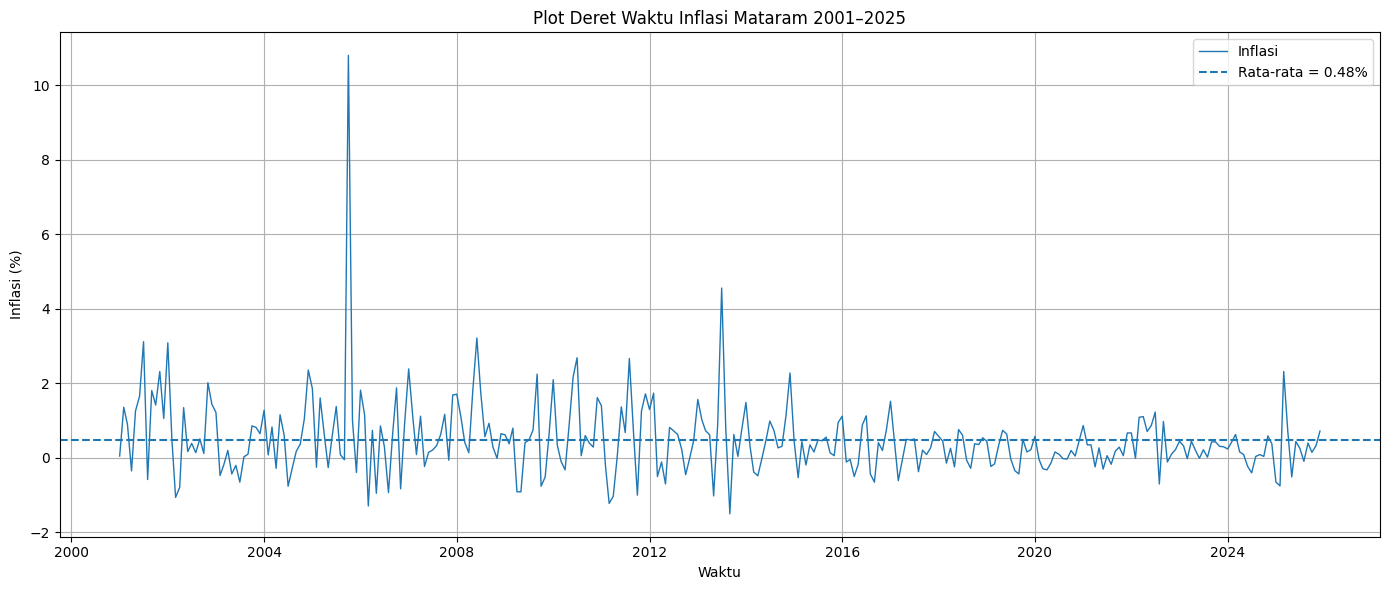

In [54]:
plt.figure(figsize=(14, 6))

plt.plot(
    ts.index,
    ts.values,
    linewidth=1,
    label="Inflasi"
)

plt.axhline(
    ts.mean(),
    linestyle="--",
    label=f"Rata-rata = {ts.mean():.2f}%"
)

plt.title("Plot Deret Waktu Inflasi Mataram 2001–2025")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()

plt.tight_layout()
plt.show()


Berdasarkan plot deret waktu di atas, inflasi Kota Mataram terlihat berfluktuasi di sekitar rata-rata 0,48%. Secara visual, deret waktu ini tidak menunjukkan adanya pola tren jangka panjang, sehingga data cenderung stasioner dalam rata-rata. Namun terdapat lonjakan ekstrem pada 2005 (10,80%), serta lonjakan lebih kecil pada 2013 (4,55%). Ketidakkonstanan lebar fluktuasi ini menjadi indikasi bahwa varians data tidak homogen, atau belum stasioner dalam ragam.

**7. Statistik Deskriptif**

In [55]:
print("Mean     :", ts.mean())
print("Median   :", ts.median())
print("Variance :", ts.var())
print("Std Dev  :", ts.std())
print("Minimum  :", ts.min())
print("Maximum  :", ts.max())

Mean     : 0.4772
Median   : 0.355
Variance : 1.031182769230769
Std Dev  : 1.0154716978974692
Minimum  : -1.51
Maximum  : 10.8


Nilai rata-rata (0,4772) yang lebih besar dari median (0,355) menunjukkan distribusi menceng ke kanan (right-skewed) yang dipicu oleh nilai ekstrem maksimum sebesar 10,8. Selain itu, rentang (range) data antara minimum (-1,51) dan maksimum (10,80) yang sangat lebar dibandingkan dengan simpangan bakunya (1,015) mengonfirmasi adanya outlier signifikan.

**8. Rolling Mean**

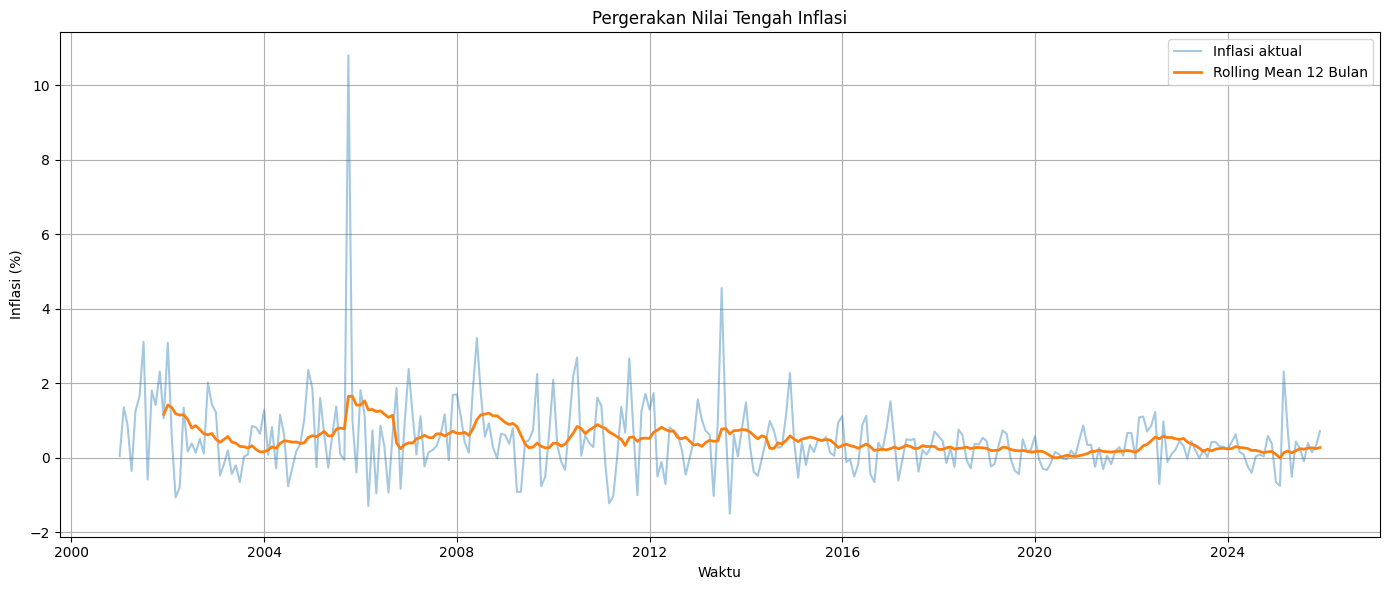

In [56]:
rolling_mean = ts.rolling(window=12).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    ts,
    alpha=0.4,
    label="Inflasi aktual"
)

plt.plot(
    rolling_mean,
    linewidth=2,
    label="Rolling Mean 12 Bulan"
)

plt.title("Pergerakan Nilai Tengah Inflasi")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()

plt.tight_layout()
plt.show()

Garis rolling mean (oranye) bergerak relatif stabil di kisaran 0%–1,5% sepanjang periode 2001–2025, jauh lebih halus dibandingkan data aktual (biru) yang sangat fluktuatif. Hal ini menunjukkan bahwa dalam jangka menengah 12 bulan, nilai tengah inflasi Mataram cenderung konsisten tanpa tren naik/turun jangka panjang, memperkuat indikasi bahwa data stasioner dalam rata-rata.

Kenaikan rolling mean yang tampak jelas pada sekitar 2005–2006 merupakan dampak dari lonjakan ekstrem inflasi yang mencapai 10,80%, namun rolling mean cepat kembali turun ke level normal setelah lonjakan tersebut mereda menandakan lonjakan bersifat sementara (shock), bukan perubahan struktural pada rata-rata jangka panjang. Sejak 2016 hingga 2025, rolling mean terlihat semakin mendatar dan berada pada level yang lebih rendah (mendekati 0%), mengindikasikan inflasi Mataram semakin stabil dan terkendali pada dekade terakhir.

**9. Rolling Standar Deviasi**

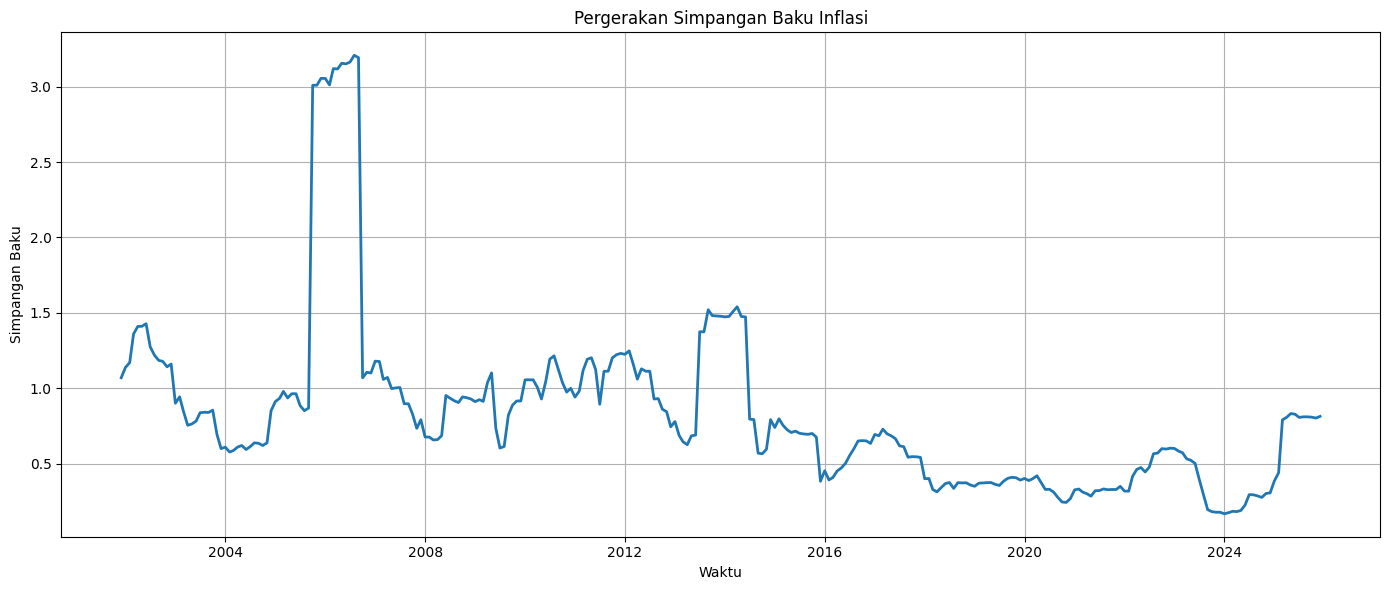

In [57]:
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(14, 6))

plt.plot(
    rolling_std,
    linewidth=2
)

plt.title("Pergerakan Simpangan Baku Inflasi")
plt.xlabel("Waktu")
plt.ylabel("Simpangan Baku")

plt.tight_layout()
plt.show()

Simpangan baku bergerak (rolling std) berfluktuasi cukup lebar, berkisar antara 0,2 hingga 3,2, jauh lebih tidak stabil dibandingkan pola rolling mean. Lonjakan tertinggi terjadi pada periode 2005–2006, mencapai sekitar 3,0–3,2, sebelum turun tajam ke kisaran 1,0 di akhir 2006. Lonjakan kedua yang lebih kecil terlihat pada 2013–2014, dengan simpangan baku mencapai sekitar 1,5.

Pola ini menunjukkan bahwa varians inflasi tidak konstan sepanjang waktu (heteroskedastisitas), sehingga data belum sepenuhnya stasioner dalam ragam. Namun sejak sekitar 2016 hingga 2025, simpangan baku cenderung menurun dan berada pada level yang lebih rendah serta stabil (umumnya di bawah 1,0), mengindikasikan volatilitas inflasi Mataram semakin berkurang pada dekade terakhir dibandingkan periode 2001–2015.

**10. Scatterplot lag 1**

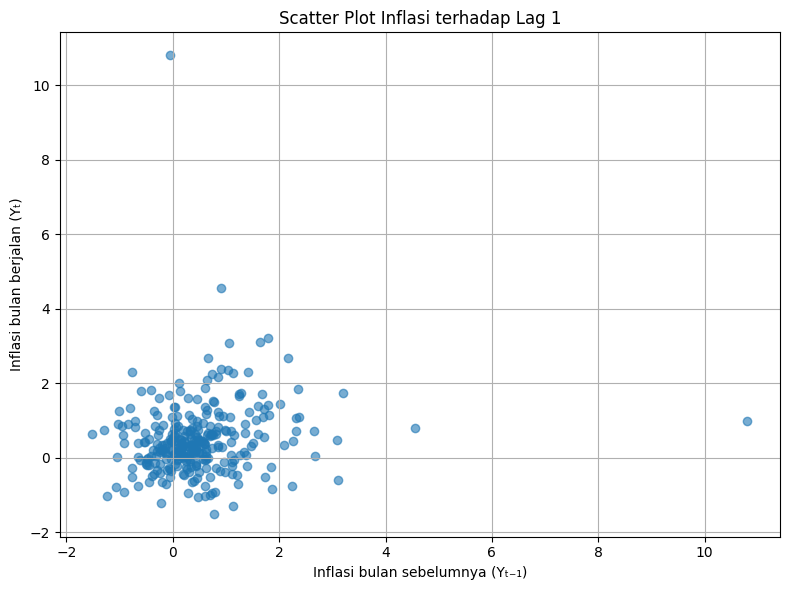

In [58]:
lag1 = pd.DataFrame({
    "Inflasi_t": ts,
    "Inflasi_t-1": ts.shift(1)
}).dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    lag1["Inflasi_t-1"],
    lag1["Inflasi_t"],
    alpha=0.6
)

plt.xlabel("Inflasi bulan sebelumnya (Yₜ₋₁)")
plt.ylabel("Inflasi bulan berjalan (Yₜ)")
plt.title("Scatter Plot Inflasi terhadap Lag 1")

plt.tight_layout()
plt.show()

Scatter plot antara inflasi bulan berjalan dan inflasi satu bulan sebelumnya menunjukkan titik-titik data tersebar tanpa membentuk pola linear yang jelas, mayoritas terkumpul di sekitar nilai 0–2 pada kedua sumbu. Tidak terlihat arah hubungan yang konsisten (baik naik maupun turun) antara inflasi bulan berjalan dengan inflasi bulan sebelumnya, menunjukkan bahwa hubungan linear antara inflasi saat ini dengan inflasi satu bulan sebelumnya lemah. Terlihat juga satu titik outlier ekstrem pada nilai 10,80% (Oktober 2005) yang terpisah jauh dari kelompok data utama, yang berpotensi menjadi leverage point saat pendugaan parameter model AR/MA nantinya.

**11. Scatterplot lag 12**

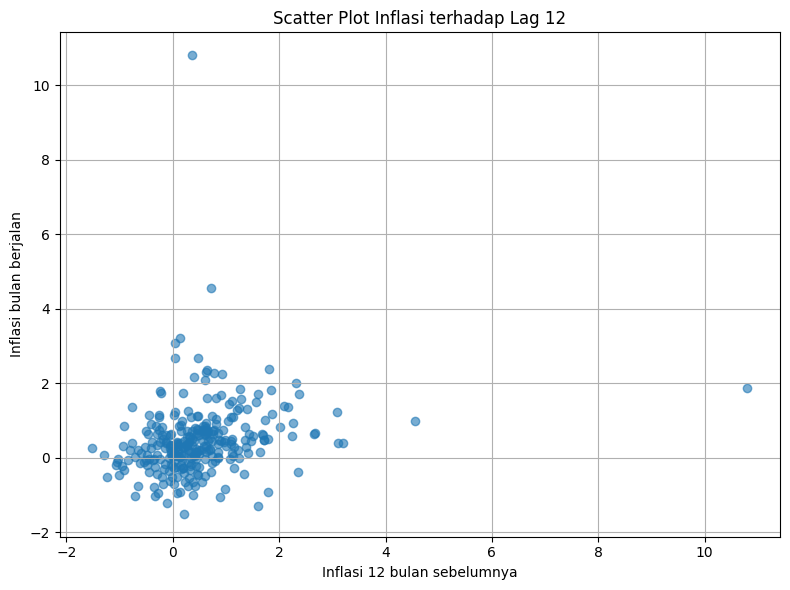

In [59]:
lag12 = pd.DataFrame({
    "Inflasi_t": ts,
    "Inflasi_t-12": ts.shift(12)
}).dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    lag12["Inflasi_t-12"],
    lag12["Inflasi_t"],
    alpha=0.6
)

plt.xlabel("Inflasi 12 bulan sebelumnya")
plt.ylabel("Inflasi bulan berjalan")
plt.title("Scatter Plot Inflasi terhadap Lag 12")

plt.tight_layout()
plt.show()

Serupa dengan lag 1, sebaran titik pada scatter plot lag 12 juga tidak menunjukkan pola linear yang jelas antara inflasi bulan berjalan dengan inflasi 12 bulan sebelumnya, dengan mayoritas titik terkumpul di sekitar nilai 0–2. Hal ini mengindikasikan bahwa autokorelasi musiman pada Lag 12 tergolong lemah. Titik outlier ekstrem (10,80%) juga tetap terlihat terpisah dari kelompok data utama pada plot ini.

**12. Boxplot**

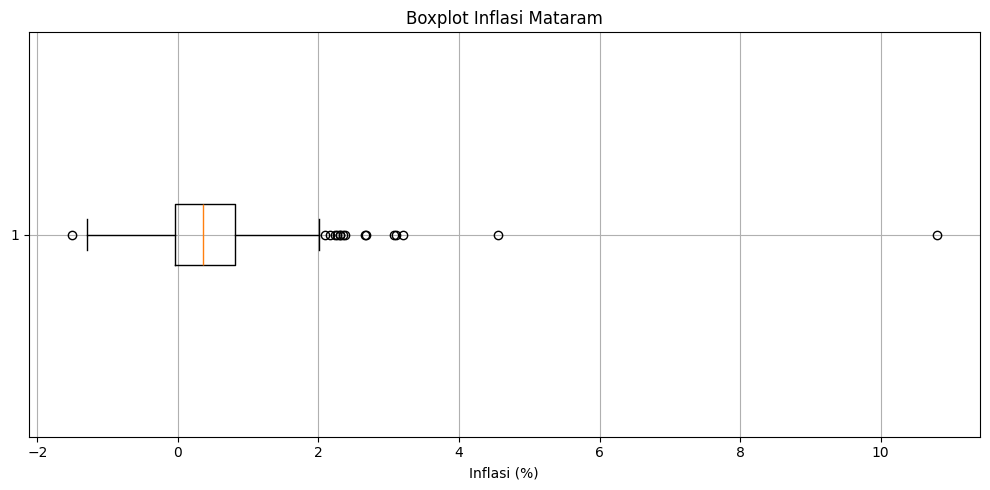

In [60]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    ts,
    vert=False
)

plt.xlabel("Inflasi (%)")
plt.title("Boxplot Inflasi Mataram")

plt.tight_layout()
plt.show()

Boxplot secara keseluruhan memperlihatkan sebaran data yang memiliki banyak pencilan (outliers) di kedua ekor distribusinya. Sepuluh nilai tertinggi didominasi oleh inflasi Oktober 2005 (10,80%) yang nilainya menjauh signifikan dari data lainnya (nilai tertinggi kedua hanya 4,55%), sementara deflasi terdalam terjadi pada September 2013 (-1,51%).

- melihat data tertinggi dan terendah

In [61]:
print("10 nilai inflasi tertinggi:")
print(ts.nlargest(10))

print("\n10 nilai inflasi terendah:")
print(ts.nsmallest(10))

10 nilai inflasi tertinggi:
tahun
2005-10-01    10.80
2013-07-01     4.55
2008-06-01     3.21
2001-07-01     3.11
2002-01-01     3.08
2010-07-01     2.68
2011-08-01     2.66
2007-01-01     2.38
2004-12-01     2.35
2001-11-01     2.31
Name: inflasi, dtype: float64

10 nilai inflasi terendah:
tahun
2013-09-01   -1.51
2006-03-01   -1.30
2011-03-01   -1.23
2002-03-01   -1.07
2011-04-01   -1.04
2013-05-01   -1.03
2011-10-01   -1.01
2006-05-01   -0.96
2006-08-01   -0.94
2009-04-01   -0.92
Name: inflasi, dtype: float64


**13. Boxplot berdasarkan bulan**

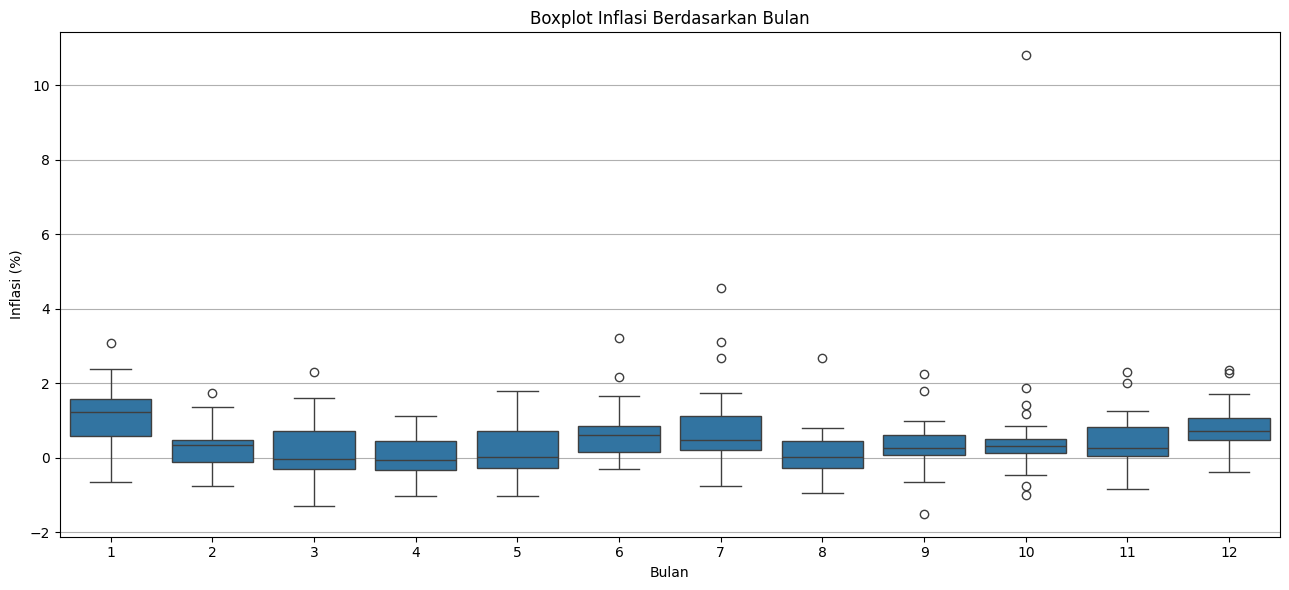

In [62]:
df["bulan"] = df["tahun"].dt.month

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df,
    x="bulan",
    y="inflasi"
)

plt.title("Boxplot Inflasi Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Inflasi (%)")

plt.tight_layout()
plt.show()

Median inflasi tertinggi terjadi pada bulan Januari (±1,2%), sementara bulan lainnya berkisar antara 0%–0,7%, mengindikasikan kecenderungan inflasi lebih tinggi di awal tahun (pola musiman). Sebaran data juga bervariasi antar bulan, dengan outlier paling ekstrem terlihat pada bulan Oktober (10,80%) dan September (-1,51%). Lebar kotak (Interquartile Range) yang bervariasi antar bulan juga kembali menegaskan adanya heteroskedastisitas sepanjang tahun.

**14. Dekomposisi STL**

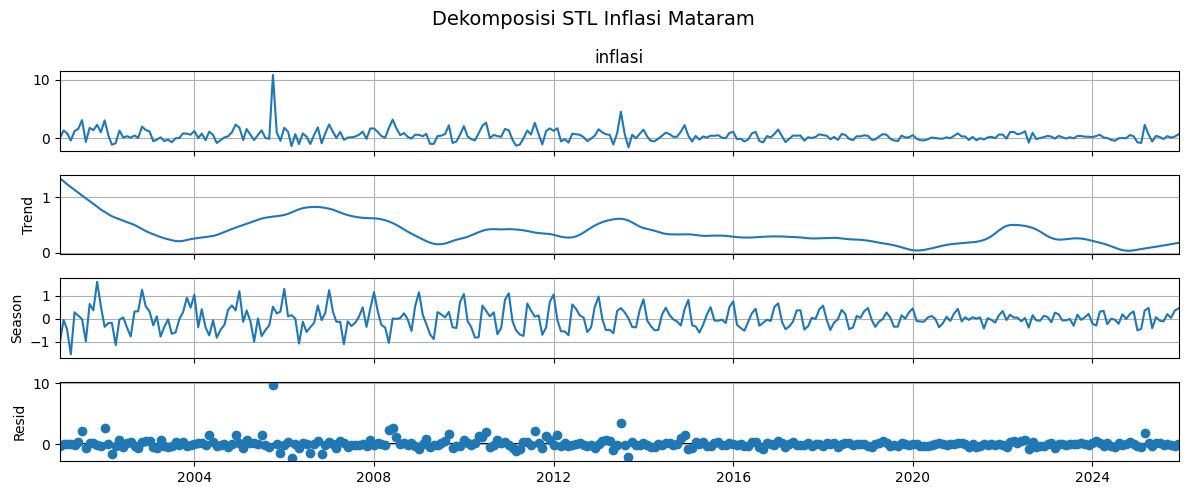

In [63]:
stl = STL(
    ts,
    period=12,
    robust=True
)

hasil_stl = stl.fit()

hasil_stl.plot()

plt.suptitle(
    "Dekomposisi STL Inflasi Mataram",
    fontsize=14
)

plt.tight_layout()
plt.show()

Trend: Bergerak pada rentang yang sempit tanpa pola naik/turun jangka panjang, menegaskan bahwa deret waktu ini tidak memiliki tren kuat dan stasioner dalam rata-rata.

Seasonal: Menunjukkan pola bulanan yang berulang secara konsisten setiap tahunnyan, mengonfirmasi adanya musiman bulanan.

Residual (Sisaan): Sebagian besar sisaan berfluktuasi stabil di sekitar angka 0, kecuali satu lonjakan residu ekstrem pada 2005. Hal ini membuktikan bahwa lonjakan tersebut murni merupakan guncangan (shock) eksternal yang tidak bisa dijelaskan oleh pola tren maupun musiman, dan menjadi pemicu utama ketidakstabilan varians data.

**15. Pembagian Data Training dan Testing**

--- Jumlah Data Observasi ---
Skenario 1 (2017) -> Train: 192 bulan, Test: 108 bulan
Skenario 2 (2020) -> Train: 228 bulan, Test: 72 bulan
Skenario 3 (2023) -> Train: 264 bulan, Test: 36 bulan
------------------------------


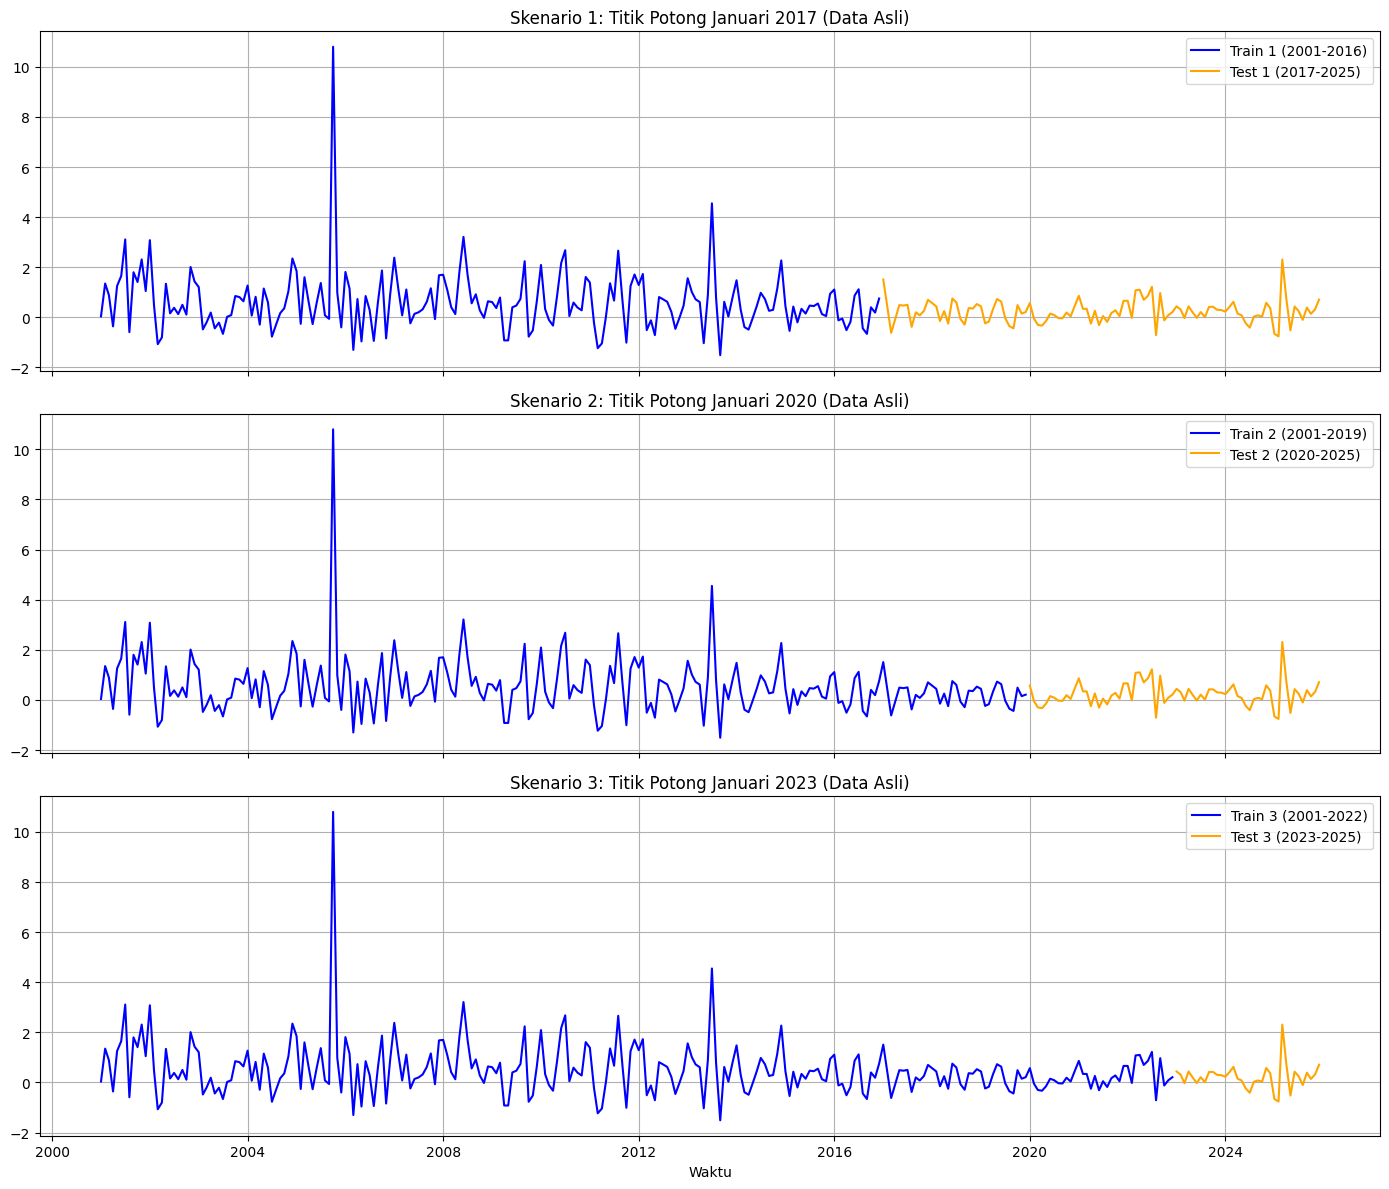

In [64]:
import matplotlib.pyplot as plt

# Karena indeks kita adalah datetime, kita bisa memotongnya menggunakan .loc berdasarkan tanggal (Tahun-Bulan-Tanggal)

# ==========================================
# Skenario 1: Titik potong Januari 2017
# ==========================================
train_1 = ts.loc[:'2016-12-01']
test_1  = ts.loc['2017-01-01':]

# ==========================================
# Skenario 2: Titik potong Januari 2020
# ==========================================
train_2 = ts.loc[:'2019-12-01']
test_2  = ts.loc['2020-01-01':]

# ==========================================
# Skenario 3: Titik potong Januari 2023
# ==========================================
train_3 = ts.loc[:'2022-12-01']
test_3  = ts.loc['2023-01-01':]

# Menampilkan jumlah data masing-masing skenario
print("--- Jumlah Data Observasi ---")
print(f"Skenario 1 (2017) -> Train: {len(train_1)} bulan, Test: {len(test_1)} bulan")
print(f"Skenario 2 (2020) -> Train: {len(train_2)} bulan, Test: {len(test_2)} bulan")
print(f"Skenario 3 (2023) -> Train: {len(train_3)} bulan, Test: {len(test_3)} bulan")
print("-" * 30)

# Visualisasi 3 Skenario sekaligus
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot Skenario 1
axes[0].plot(train_1.index, train_1.values, label="Train 1 (2001-2016)", color="blue")
axes[0].plot(test_1.index, test_1.values, label="Test 1 (2017-2025)", color="orange")
axes[0].set_title("Skenario 1: Titik Potong Januari 2017 (Data Asli)")
axes[0].legend()
axes[0].grid(True)

# Plot Skenario 2
axes[1].plot(train_2.index, train_2.values, label="Train 2 (2001-2019)", color="blue")
axes[1].plot(test_2.index, test_2.values, label="Test 2 (2020-2025)", color="orange")
axes[1].set_title("Skenario 2: Titik Potong Januari 2020 (Data Asli)")
axes[1].legend()
axes[1].grid(True)

# Plot Skenario 3
axes[2].plot(train_3.index, train_3.values, label="Train 3 (2001-2022)", color="blue")
axes[2].plot(test_3.index, test_3.values, label="Test 3 (2023-2025)", color="orange")
axes[2].set_title("Skenario 3: Titik Potong Januari 2023 (Data Asli)")
axes[2].legend()
axes[2].grid(True)

plt.xlabel("Waktu")
plt.tight_layout()
plt.show()

**16. Eksplorasi Data Training**

=== EKSPLORASI DATA ASLI (SEBELUM TRANSFORMASI) ===

--- Skenario 1 (2001-2016) ---
P-Value ADF          : 9.2952e-07
Kesimpulan ADF       : SUDAH Stasioner (d=0)


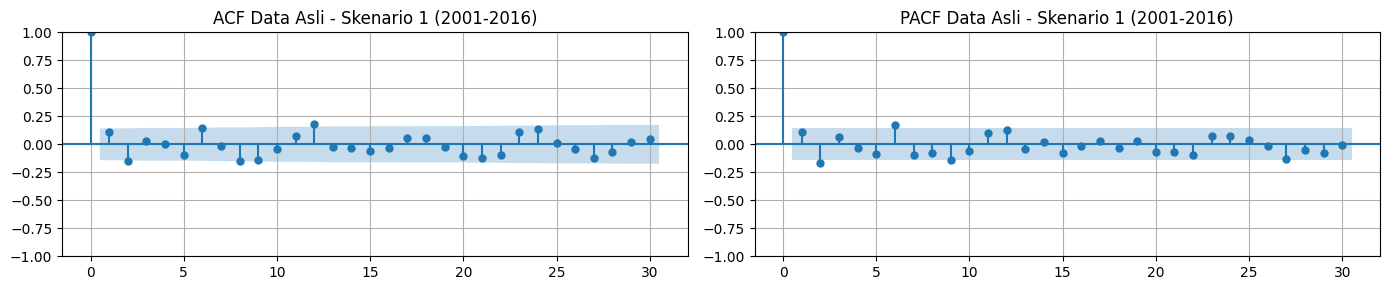

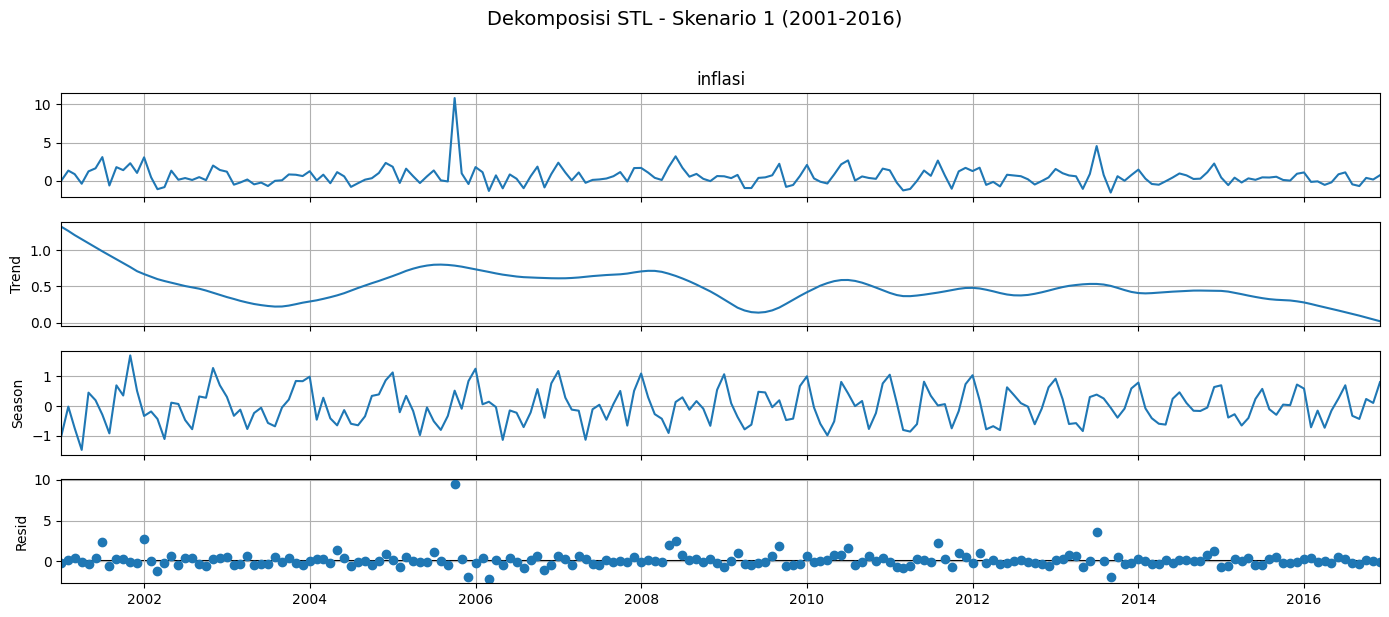


--- Skenario 2 (2001-2019) ---
P-Value ADF          : 2.2550e-03
Kesimpulan ADF       : SUDAH Stasioner (d=0)


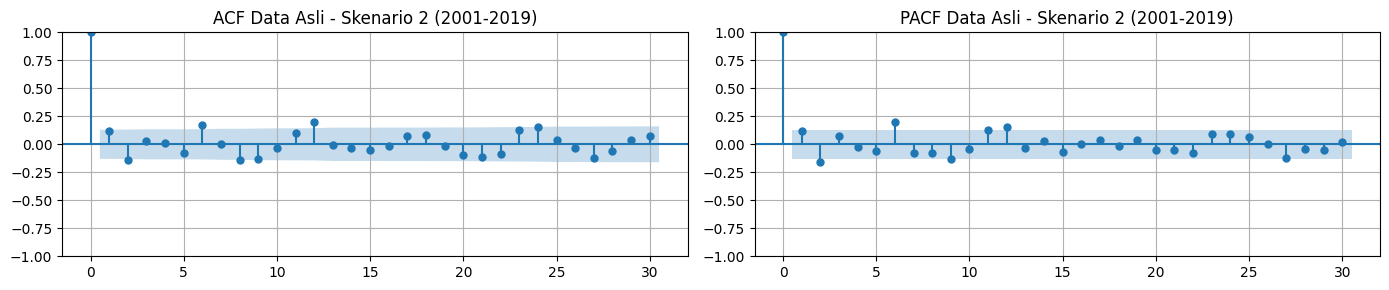

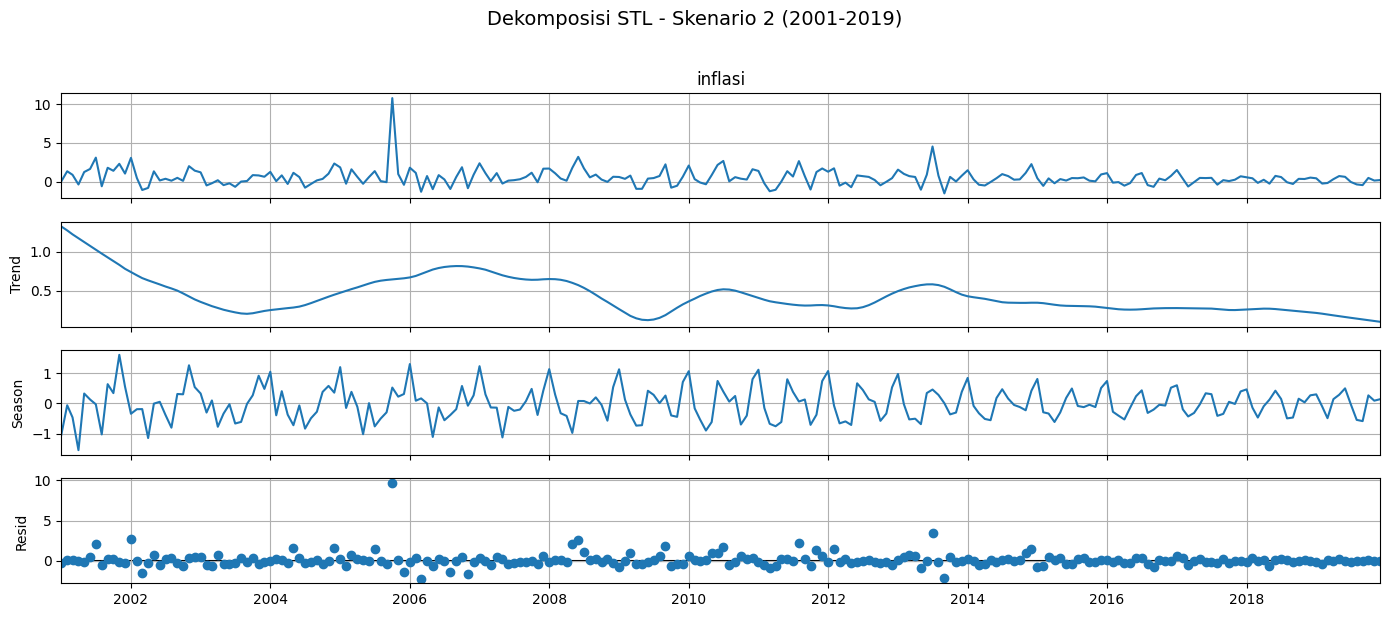


--- Skenario 3 (2001-2022) ---
P-Value ADF          : 1.2026e-03
Kesimpulan ADF       : SUDAH Stasioner (d=0)


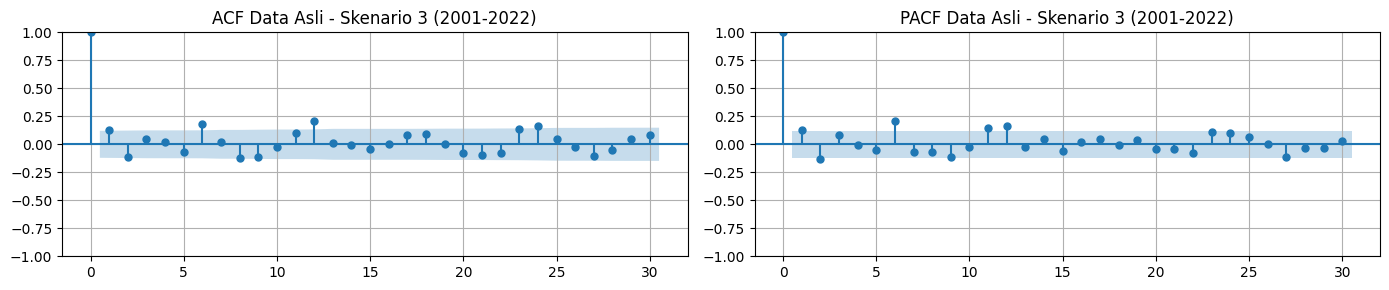

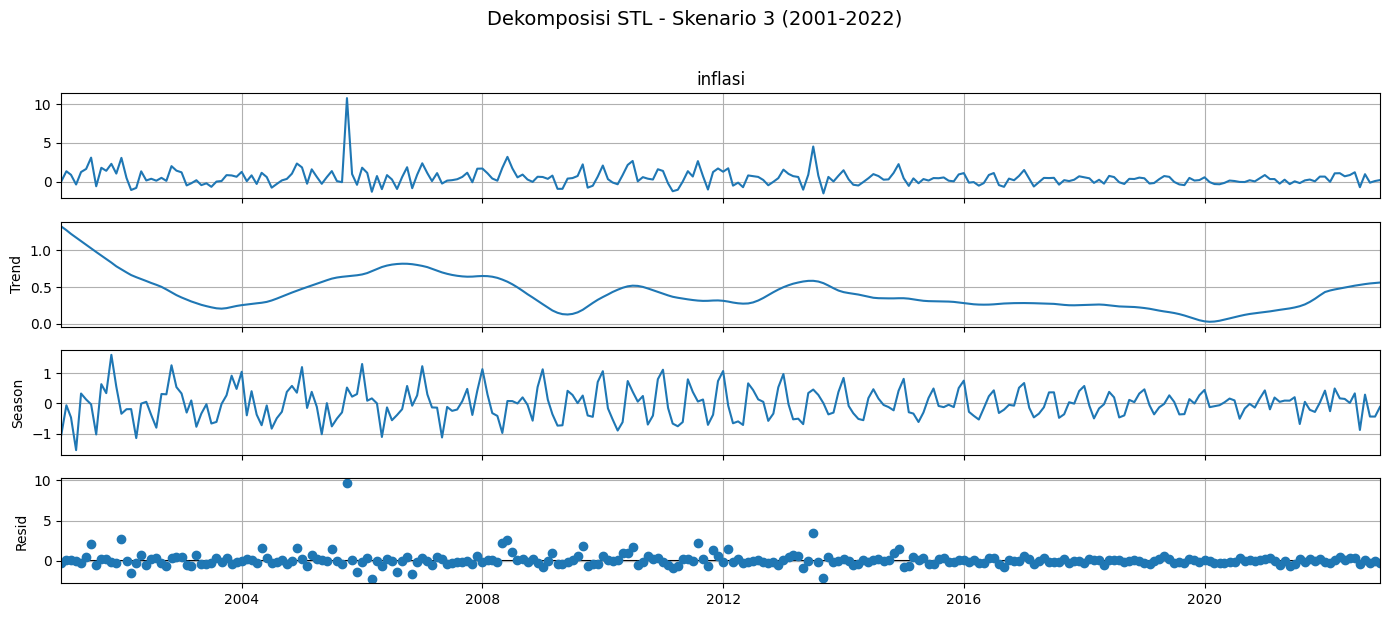

In [66]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 0. Definisikan dictionary skenario_train agar bisa di-looping
skenario_train = {
    "Skenario 1 (2001-2016)": train_1,
    "Skenario 2 (2001-2019)": train_2,
    "Skenario 3 (2001-2022)": train_3
}

print("=== EKSPLORASI DATA ASLI (SEBELUM TRANSFORMASI) ===\n")

# Looping untuk ketiga skenario data latih
for nama, train_data in skenario_train.items():
    print(f"--- {nama} ---")

    # 1. Uji ADF Sebelum Transformasi
    adf_sebelum = adfuller(train_data)
    p_value_sebelum = adf_sebelum[1]
    print(f"P-Value ADF          : {p_value_sebelum:.4e}")
    if p_value_sebelum < 0.05:
        print("Kesimpulan ADF       : SUDAH Stasioner (d=0)")
    else:
        print("Kesimpulan ADF       : BELUM Stasioner (Butuh Differencing / d>0)")

    # 2. Visualisasi ACF dan PACF Data Asli
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    plot_acf(train_data, lags=30, ax=axes[0])
    axes[0].set_title(f"ACF Data Asli - {nama}")

    plot_pacf(train_data, lags=30, ax=axes[1])
    axes[1].set_title(f"PACF Data Asli - {nama}")
    plt.tight_layout()
    plt.show()

    # 3. Dekomposisi STL (Seasonal and Trend using Loess)
    # Periode 12 karena data bulanan
    stl = STL(train_data, period=12, robust=True)
    hasil_stl = stl.fit()

    fig = hasil_stl.plot()
    fig.set_size_inches(14, 6)
    fig.suptitle(f"Dekomposisi STL - {nama}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    print("="*60 + "\n")

Uji ADF (Stasioneritas Rata-rata): P-value untuk ketiga skenario bernilai sangat kecil, yaitu Skenario 1 (9.2952e-07), Skenario 2 (2.2550e-03), dan Skenario 3 (1.2026e-03). Karena seluruh p-value < 0.05, ini membuktikan secara statistik bahwa data asli di ketiga skenario sudah stasioner dalam rata-rata. Model kita dipastikan tidak memerlukan proses differencing (d=0).

Plot ACF dan PACF: Terdapat garis lag awal (seperti lag 1 dan 2) yang keluar dari area bayangan biru pada ketiga skenario, yang mengindikasikan kandidat ordo AR atau MA. Namun, temuan paling krusial adalah adanya lonjakan (spike) yang signifikan tepat di lag 12 pada plot ACF maupun PACF. Ini adalah sinyal kuat adanya pola musiman tahunan (12 bulan).

Dekomposisi STL:
- Trend: Garis tren bergerak dinamis namun tidak menunjukkan kenaikan atau penurunan ekstrem jangka panjang, sejalan dengan hasil uji ADF yang menyatakan data stasioner.
- Season (Musiman): Plot season di ketiga skenario menampilkan pola gelombang yang berulang dengan sangat rapi dan identik setiap tahunnya. Ini mempertegas sinyal dari plot ACF/PACF bahwa model kita sebaiknya mengakomodasi komponen musiman (SARIMA), bukan sekadar ARMA biasa.
- Resid (Sisaan/Noise): Plot sisaan mendeteksi dengan sangat jelas keberadaan outlier raksasa di sekitar tahun 2005-2006 (titik biru yang melompat mendekati angka 10). Ini adalah bukti visual mutlak bahwa ragam (varians) data tidak stasioner/tidak konstan.

Kesimpulan akhirnya: Data siap diproses tanpa differencing, namun kita wajib melakukan transformasi Box-Cox untuk menjinakkan ragam yang liar akibat outlier di tahun 2005.

Fungsi boxcox yang kita gunakan untuk mencari nilai lambda ($\lambda$) optimal sebenarnya bertindak sebagai detektif sekaligus dokter:

- Jika $\lambda \approx 1$, artinya ragam data aslinya sudah stasioner dan algoritma tidak akan merubah bentuk datanya.
- Jika $\lambda$ jauh dari angka 1 (misalnya 0, 0.5, atau negatif), ini secara matematis mengonfirmasi bahwa ragam memang tidak stasioner, dan algoritma akan langsung mentransformasikannya agar stabil saat itu juga.

**17. Transformasi Box-Cox & Uji ADF**

In [67]:
from scipy.stats import boxcox

print("=== TRANSFORMASI BOX-COX DAN UJI ADF DATA TRANSFORMASI ===\n")

# Dictionary untuk menyimpan hasil Box-Cox (data latih, lambda, dan shift) per skenario
hasil_boxcox = {}

# Mencari nilai shift global dari data asli (ts) agar seragam
konstanta_shift = abs(ts.min()) + 1

for nama, train_data in skenario_train.items():
    print(f"--- {nama} ---")

    # 1. Menambahkan shift agar tidak ada data negatif
    train_shifted = train_data + konstanta_shift

    # 2. Transformasi Box-Cox
    train_bc_array, opt_lambda = boxcox(train_shifted)
    train_bc = pd.Series(train_bc_array, index=train_data.index)

    # Simpan hasil untuk keperluan pemodelan dan inverse-transform nanti
    hasil_boxcox[nama] = {
        'train_bc': train_bc,
        'lambda': opt_lambda,
        'shift': konstanta_shift
    }

    # 3. Uji ADF Sesudah Transformasi
    adf_sesudah = adfuller(train_bc)
    p_value_sesudah = adf_sesudah[1]

    print(f"Nilai Lambda Optimal : {opt_lambda:.4f}")
    print(f"P-Value ADF (Box-Cox): {p_value_sesudah:.4e}")
    if p_value_sesudah < 0.05:
        print("Kesimpulan ADF       : Tetap Stasioner (d=0)\n")
    else:
        print("Kesimpulan ADF       : Menjadi TIDAK Stasioner (Butuh d>0)\n")

=== TRANSFORMASI BOX-COX DAN UJI ADF DATA TRANSFORMASI ===

--- Skenario 1 (2001-2016) ---
Nilai Lambda Optimal : -0.0319
P-Value ADF (Box-Cox): 5.7815e-04
Kesimpulan ADF       : Tetap Stasioner (d=0)

--- Skenario 2 (2001-2019) ---
Nilai Lambda Optimal : -0.0814
P-Value ADF (Box-Cox): 3.3940e-04
Kesimpulan ADF       : Tetap Stasioner (d=0)

--- Skenario 3 (2001-2022) ---
Nilai Lambda Optimal : -0.1162
P-Value ADF (Box-Cox): 1.3009e-04
Kesimpulan ADF       : Tetap Stasioner (d=0)



Berdasarkan hasil uji pada gambar, nilai lambda optimal untuk ketiga skenario bernilai negatif dan mendekati nol (-0,0319, -0,0814, dan -0,1162). Ini mengonfirmasi bahwa data asli memang memiliki masalah ragam yang tidak konstan, dan algoritma menerapkan transformasi yang sifatnya hampir menyerupai transformasi logaritma natural. Selain itu, p-value Uji ADF setelah Box-Cox untuk semua skenario sangat kecil (jauh di bawah taraf nyata 0,05). Artinya, stasioneritas rata-rata tetap terjaga dengan sangat baik setelah transformasi, sehingga kita sah menggunakan nilai d=0.

**18. Plot Deret Waktu, ACF, PACF dan rolling stdev setelah transformasi**

=== VISUALISASI EKSPLORASI SETELAH TRANSFORMASI BOX-COX ===



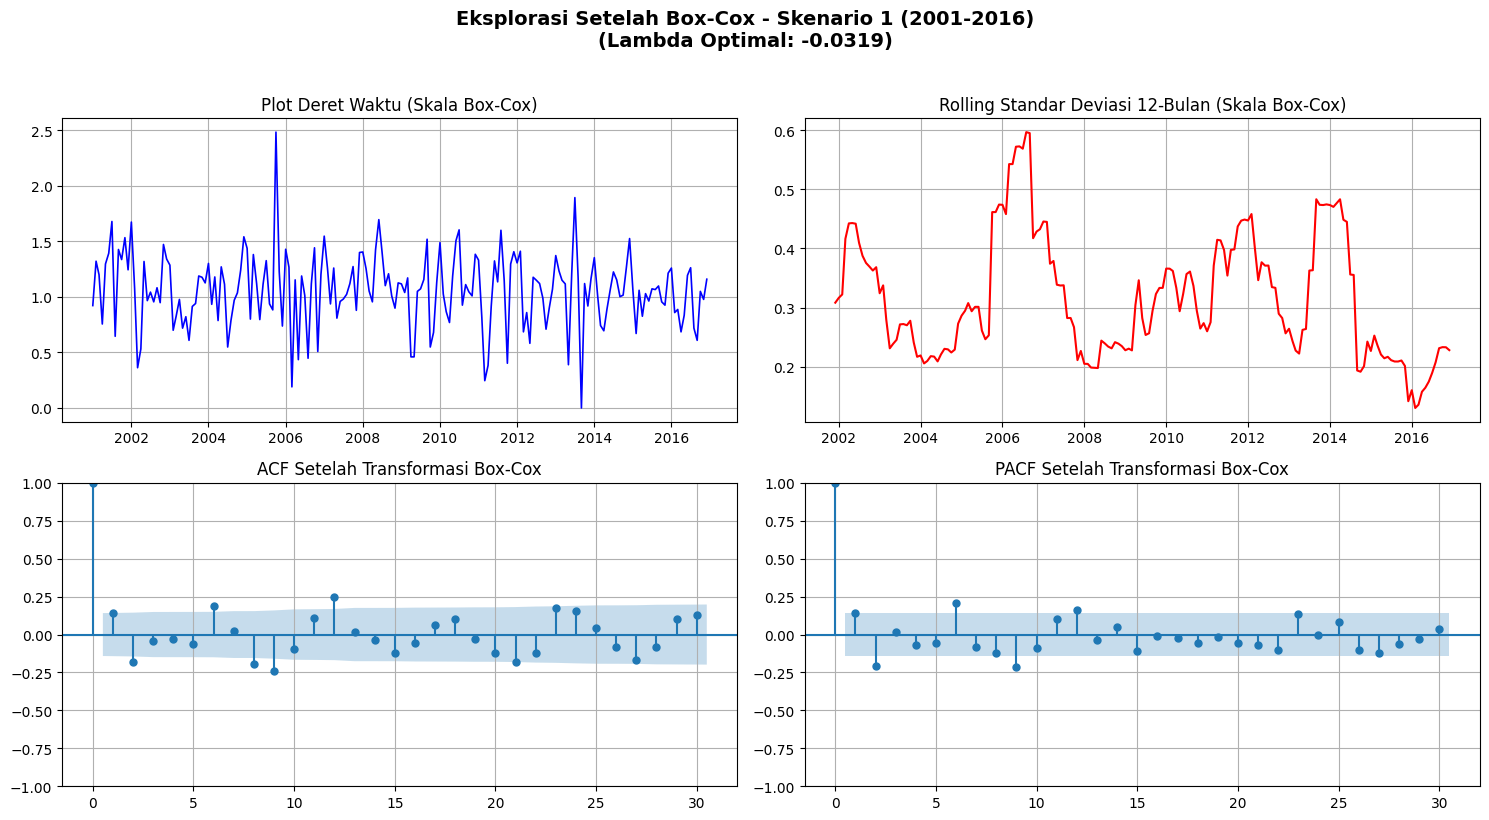

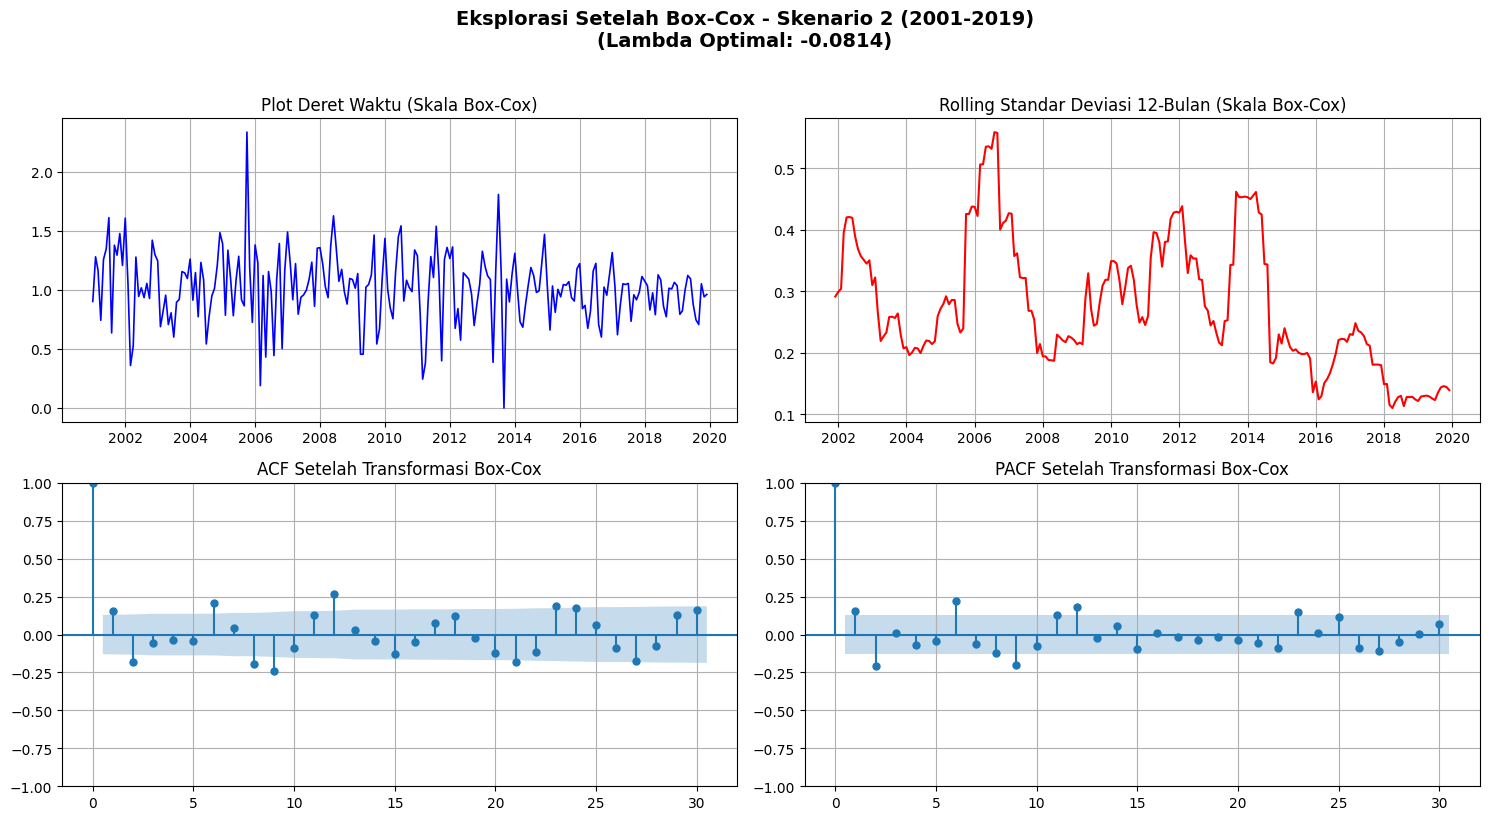

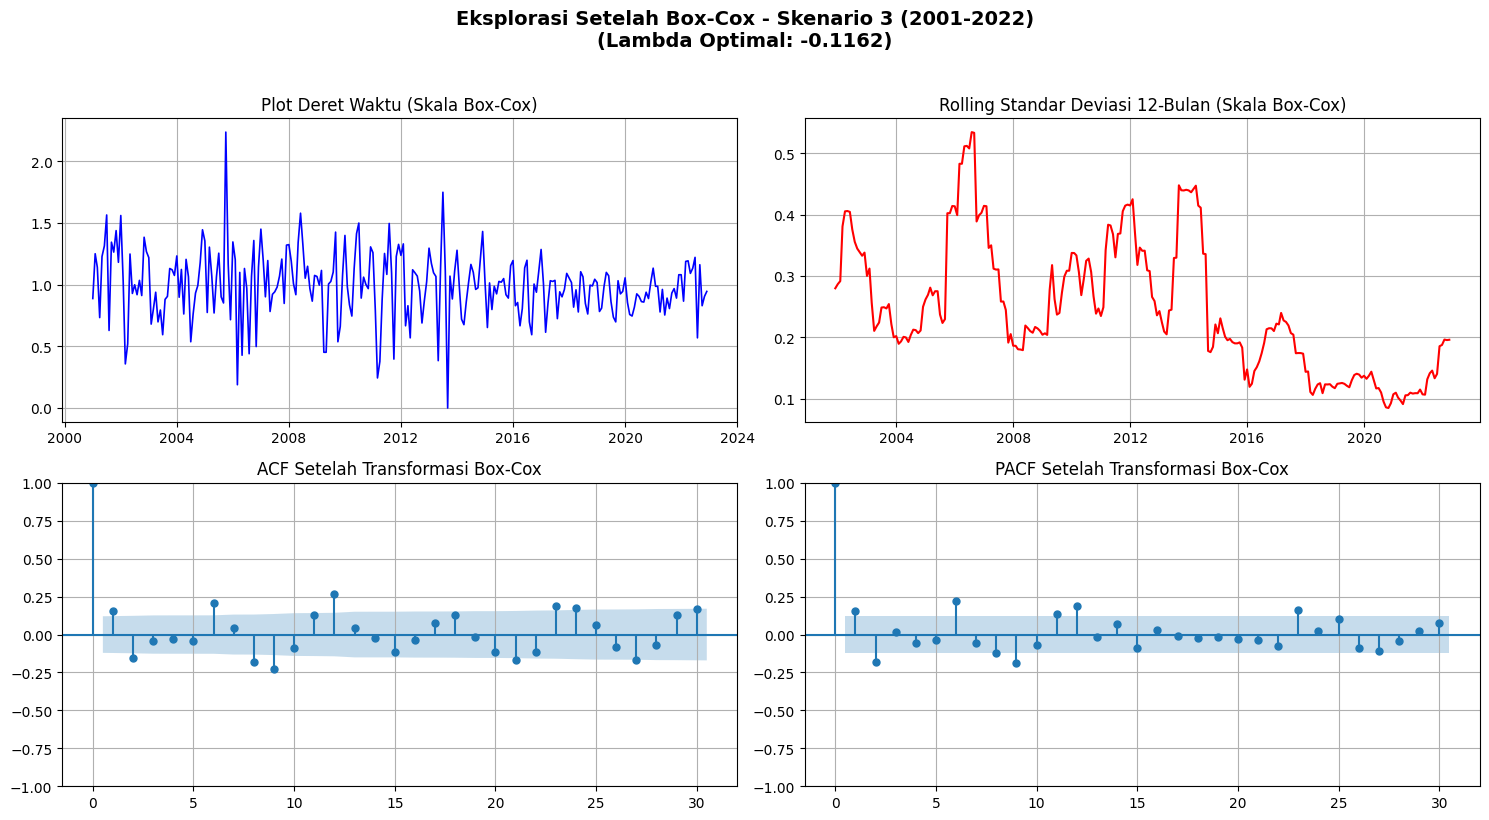

In [68]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("=== VISUALISASI EKSPLORASI SETELAH TRANSFORMASI BOX-COX ===\n")

# Looping untuk setiap skenario yang sudah disimpan di hasil_boxcox
for nama, data_dict in hasil_boxcox.items():
    train_bc = data_dict['train_bc']
    opt_lambda = data_dict['lambda']

    # Membuat grid 2 baris x 2 kolom untuk plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    fig.suptitle(f"Eksplorasi Setelah Box-Cox - {nama}\n(Lambda Optimal: {opt_lambda:.4f})", fontsize=14, fontweight='bold', y=1.02)

    # 1. Plot Data Latih Transformasi Box-Cox
    axes[0, 0].plot(train_bc.index, train_bc.values, color='blue', linewidth=1.2)
    axes[0, 0].set_title("Plot Deret Waktu (Skala Box-Cox)")
    axes[0, 0].grid(True)

    # 2. Plot Rolling Standar Deviasi
    rolling_std_bc = train_bc.rolling(window=12).std()
    axes[0, 1].plot(rolling_std_bc.index, rolling_std_bc.values, color='red', linewidth=1.5)
    axes[0, 1].set_title("Rolling Standar Deviasi 12-Bulan (Skala Box-Cox)")
    axes[0, 1].grid(True)

    # 3. Plot ACF Setelah Transformasi
    plot_acf(train_bc, lags=30, ax=axes[1, 0])
    axes[1, 0].set_title("ACF Setelah Transformasi Box-Cox")
    axes[1, 0].grid(True)

    # 4. Plot PACF Setelah Transformasi
    plot_pacf(train_bc, lags=30, ax=axes[1, 1])
    axes[1, 1].set_title("PACF Setelah Transformasi Box-Cox")
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    print("=" * 100 + "\n")

Berdasarkan visualisasi setelah transformasi Box-Cox, penyakit ragam yang tidak konstan pada data latih di ketiga skenario sudah berhasil diatasi.

- Peredaman Volatilitas Ekstrem: Pada plot Rolling Standar Deviasi (garis merah), skala sumbu Y kini mengecil drastis dengan nilai maksimal hanya berada di kisaran 0,5 hingga 0,6. Lonjakan raksasa yang sebelumnya terjadi di tahun 2005-2006 sudah berhasil diredam dan dikompresi oleh transformasi Box-Cox.
- Stabilitas Dekade Terakhir: Pada skenario 2 dan 3, terlihat jelas bahwa setelah tahun 2016, pergerakan standar deviasi sangat mendatar dan anteng di angka 0,1.
- Kandidat Ordo ARMA (ACF & PACF): Terdapat beberapa garis yang melewati batas signifikansi biru di lag-lag awal, terutama lag 1 dan lag 2 pada plot PACF di ketiga skenario. Ini menandakan komponen Auto-Regressive (AR) berordo 1 atau 2 sangat layak untuk dicoba.
- Jejak Musiman: Plot ACF dan PACF di ketiga skenario secara konsisten masih menunjukkan lonjakan (spike) yang cukup tajam tepat di lag 12. Ini menegaskan bahwa komponen musiman tahunan masih menempel pada data meskipun sudah ditransformasi

**19. Mencari 5 model terbaik berdasarkan AIC dan BIC untuk masing-masing skenario.**

In [70]:
import pandas as pd
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore") # Menyembunyikan peringatan konvergensi

print("=== PENCARIAN KANDIDAT MODEL TERBAIK (AIC & BIC) PER SKENARIO ===\n")

# Kandidat orde ARMA (p: 0-3, q: 0-3)
kandidat_p = range(0, 4)
kandidat_q = range(0, 4)

# Looping untuk setiap skenario data latih yang sudah di-Box-Cox
for nama, data_dict in hasil_boxcox.items():
    print(f"--- {nama} ---")
    train_bc = data_dict['train_bc']

    hasil_aic_bic = []

    for p in kandidat_p:
        for q in kandidat_q:
            if p == 0 and q == 0:
                continue # Lewati ARMA(0,0) karena hanya white noise

            orde = (p, 0, q)
            try:
                # Fit Model ARMA pada data latih Box-Cox
                model = ARIMA(train_bc, order=orde)
                hasil = model.fit()

                # Simpan Hasil
                hasil_aic_bic.append({
                    "Orde Model": f"ARMA{orde}",
                    "AIC": hasil.aic,
                    "BIC": hasil.bic
                })

            except:
                continue # Lewati jika model gagal konvergen

    # Membuat DataFrame dan mengurutkan berdasarkan AIC terkecil
    df_hasil = pd.DataFrame(hasil_aic_bic).sort_values(by="AIC").reset_index(drop=True)

    print("5 Kandidat Model Terbaik (Berdasarkan AIC terkecil):")
    display(df_hasil.head(5))
    print("=" * 60 + "\n")

=== PENCARIAN KANDIDAT MODEL TERBAIK (AIC & BIC) PER SKENARIO ===

--- Skenario 1 (2001-2016) ---
5 Kandidat Model Terbaik (Berdasarkan AIC terkecil):


,Orde Model,AIC,BIC
0,"ARMA(1, 0, 3)",106.225788,125.770760
1,"ARMA(3, 0, 3)",107.728395,133.788358
2,"ARMA(2, 0, 3)",108.224817,131.027284
3,"ARMA(2, 0, 0)",108.250447,121.280429
4,"ARMA(0, 0, 2)",108.946801,121.976782



--- Skenario 2 (2001-2019) ---
5 Kandidat Model Terbaik (Berdasarkan AIC terkecil):


,Orde Model,AIC,BIC
0,"ARMA(3, 0, 3)",63.318384,90.753149
1,"ARMA(1, 0, 3)",71.862943,92.439017
2,"ARMA(2, 0, 3)",73.839999,97.845418
3,"ARMA(2, 0, 0)",74.014011,87.731394
4,"ARMA(0, 0, 2)",75.099308,88.816691



--- Skenario 3 (2001-2022) ---
5 Kandidat Model Terbaik (Berdasarkan AIC terkecil):


,Orde Model,AIC,BIC
0,"ARMA(3, 0, 3)",27.581610,56.189203
1,"ARMA(1, 0, 3)",38.628877,60.084572
2,"ARMA(2, 0, 3)",39.959637,64.991281
3,"ARMA(2, 0, 0)",41.430165,55.733962
4,"ARMA(0, 0, 2)",42.197724,56.501520


- Dominasi Model Kompleks pada AIC: Model dengan orde yang lebih tinggi seperti ARMA(3,0,3) dan ARMA(1,0,3) menempati peringkat pertama berdasarkan kriteria AIC di ketiga skenario. Skenario 1 dipimpin oleh ARMA(1,0,3) dengan AIC 106,225788. Skenario 2 dan 3 dipimpin oleh ARMA(3,0,3) dengan AIC masing-masing 63,318384 dan 27,581610.
- Prinsip Parsimoni (Kesederhanaan) pada BIC: Metrik BIC memberikan penalti lebih berat pada model yang rumit. Terlihat bahwa model ARMA(2,0,0) yang jauh lebih sederhana secara konsisten masuk ke dalam Top 5 di semua skenario. Hebatnya, ARMA(2,0,0) memiliki nilai BIC yang paling rendah atau sangat kompetitif dibandingkan model peringkat pertama. Pada Skenario 1, BIC ARMA(2,0,0) adalah 121,280429 (lebih rendah dari ARMA(1,0,3) yang 125,770760). Pada Skenario 2, BIC ARMA(2,0,0) adalah 87,731394 (lebih rendah dari ARMA(3,0,3) yang 90,753149). Pada Skenario 3, BIC ARMA(2,0,0) adalah 55,733962 (lebih rendah dari ARMA(3,0,3) yang 56,189203).

Sebagai kandidat model yang akan diuji sisaannya, kita akan mengambil 2 model terbaik per skenario: satu yang mewakili AIC terbaik (model kompleks) dan satu yang mewakili BIC terbaik (model sederhana).

Skenario 1: ARMA(1,0,3) dan ARMA(2,0,0)

Skenario 2: ARMA(3,0,3) dan ARMA(2,0,0)

Skenario 3: ARMA(3,0,3) dan ARMA(2,0,0)

**20. Uji Sisaan (Ljung-Box)**

Uji Ljung-Box digunakan untuk melihat apakah sisaan (residual) dari model sudah bersifat acak (white noise). Jika p-value > 0,05, maka sisaan tidak memiliki autokorelasi (lolos uji asumsi). Jika p-value < 0,05, masih ada informasi yang tertinggal di sisaan (gagal uji asumsi).

In [71]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

warnings.filterwarnings("ignore") # Menyembunyikan peringatan konvergensi

# Daftar kandidat model terpilih per skenario (kombinasi juara AIC dan juara BIC)
kandidat_terpilih = {
    "Skenario 1 (2001-2016)": [(1, 0, 3), (2, 0, 0)],
    "Skenario 2 (2001-2019)": [(3, 0, 3), (2, 0, 0)],
    "Skenario 3 (2001-2022)": [(3, 0, 3), (2, 0, 0)]
}

print("=== UJI SISAAN (LJUNG-BOX) KANDIDAT MODEL TERPILIH ===\n")

for nama_skenario, daftar_orde in kandidat_terpilih.items():
    print(f"--- {nama_skenario} ---")
    train_bc = hasil_boxcox[nama_skenario]['train_bc']

    for orde in daftar_orde:
        try:
            # Fit model ARMA
            model = ARIMA(train_bc, order=orde)
            hasil = model.fit()

            # Ambil sisaan (residuals)
            sisaan = hasil.resid

            # Uji Ljung-Box pada lag 12 (karena data bulanan)
            # H0: Sisaan tidak memiliki autokorelasi (White Noise)
            ljung_box = acorr_ljungbox(sisaan, lags=[12], return_df=True)
            p_value_lb = ljung_box['lb_pvalue'].values[0]

            # Menentukan status kelolosan
            status = "LOLOS" if p_value_lb > 0.05 else "GAGAL"

            print(f"Model ARMA{orde}: P-Value = {p_value_lb:.4f} -> {status} Uji Autokorelasi")

        except Exception as e:
            print(f"Model ARMA{orde}: Gagal dieksekusi secara matematis")

    print("-" * 60)

=== UJI SISAAN (LJUNG-BOX) KANDIDAT MODEL TERPILIH ===

--- Skenario 1 (2001-2016) ---
Model ARMA(1, 0, 3): P-Value = 0.0066 -> GAGAL Uji Autokorelasi
Model ARMA(2, 0, 0): P-Value = 0.0013 -> GAGAL Uji Autokorelasi
------------------------------------------------------------
--- Skenario 2 (2001-2019) ---
Model ARMA(3, 0, 3): P-Value = 0.0154 -> GAGAL Uji Autokorelasi
Model ARMA(2, 0, 0): P-Value = 0.0001 -> GAGAL Uji Autokorelasi
------------------------------------------------------------
--- Skenario 3 (2001-2022) ---
Model ARMA(3, 0, 3): P-Value = 0.0086 -> GAGAL Uji Autokorelasi
Model ARMA(2, 0, 0): P-Value = 0.0000 -> GAGAL Uji Autokorelasi
------------------------------------------------------------


Hasil uji Ljung-Box menunjukkan bahwa seluruh kandidat model di ketiga skenario GAGAL memenuhi asumsi sisaan white noise. Nilai p-value dari semua model (seperti 0,0066 untuk ARMA(1,0,3) Skenario 1 atau 0,0000 untuk ARMA(2,0,0) Skenario 3) berada jauh di bawah 0,05.

Pada hasil dekomposisi STL dan plot ACF/PACF sebelumnya yang memperlihatkan pola musiman 12 bulanan yang sangat kuat. Karena kita menggunakan model ARMA/ARIMA yang non-musiman, model ini tidak mampu menangkap pola gelombang tahunan tersebut. Akibatnya, informasi musiman itu "tertinggal" di dalam sisaan (residual), yang menyebabkan sisaannya tidak acak dan saling berkolerasi.

Nanti di bab kesimpulan atau presentasi, kamu bisa menuliskan argumen emas ini:
"Evaluasi asumsi sisaan menunjukkan adanya autokorelasi karena model ARMA tidak mengakomodasi efek musiman. Sebagai saran untuk penelitian selanjutnya, performa peramalan dapat ditingkatkan dengan menggunakan model SARIMA (Seasonal ARIMA)."

**Skenario 1: Visualisasi Diagnostik Sisaan**

=== VISUALISASI DIAGNOSTIK SISAAN SKENARIO 1 ===



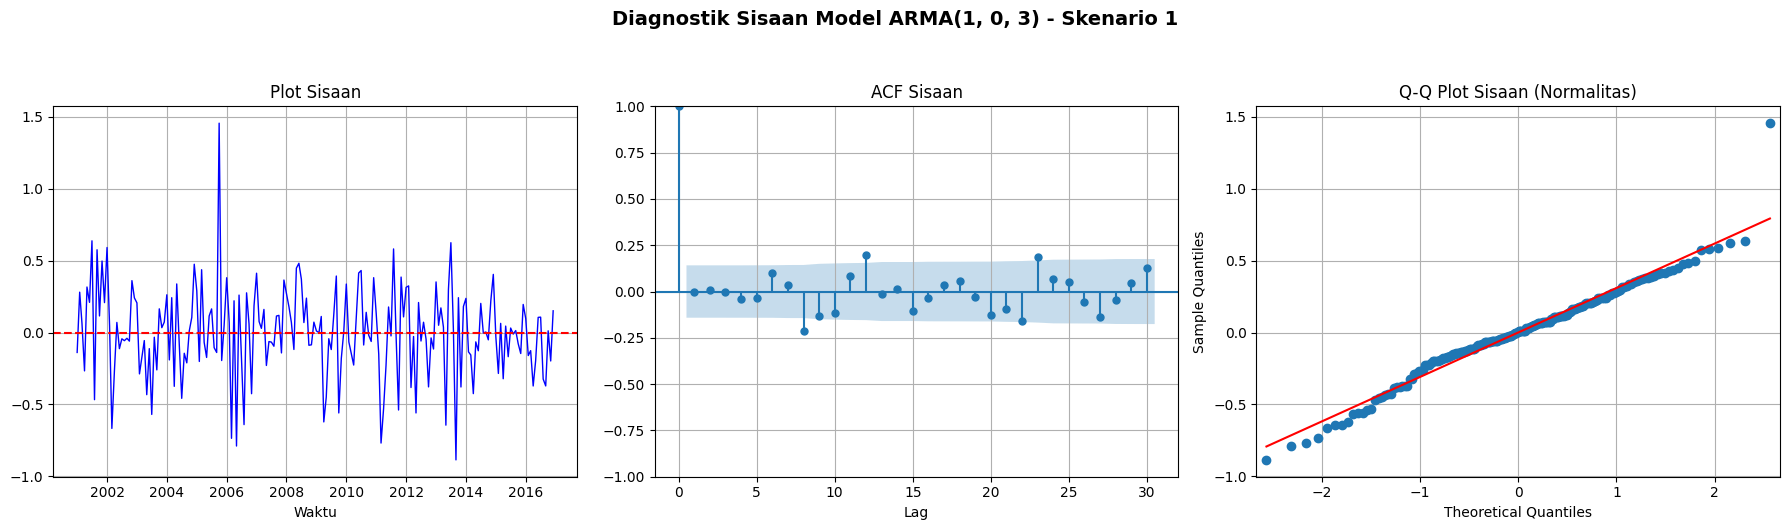

----------------------------------------------------------------------------------------------------


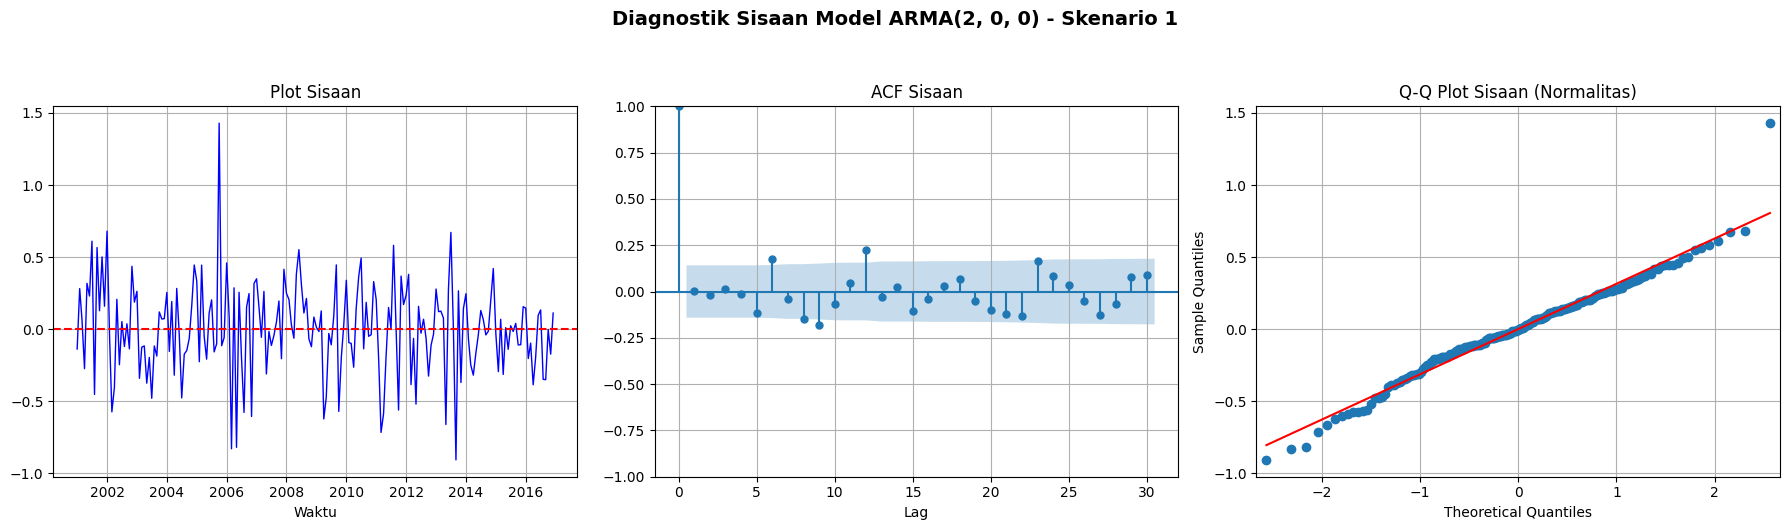

----------------------------------------------------------------------------------------------------


In [73]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

print("=== VISUALISASI DIAGNOSTIK SISAAN SKENARIO 1 ===\n")

# Mengambil data latih Box-Cox Skenario 1
train_bc = hasil_boxcox["Skenario 1 (2001-2016)"]['train_bc']

# Kandidat model Skenario 1
kandidat_skenario_1 = [(1, 0, 3), (2, 0, 0)]

for orde in kandidat_skenario_1:
    # Fit Model
    model = ARIMA(train_bc, order=orde)
    hasil = model.fit()
    sisaan = hasil.resid

    # Membuat 3 subplot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Diagnostik Sisaan Model ARMA{orde} - Skenario 1", fontsize=14, fontweight='bold', y=1.05)

    # 1. Plot Sisaan (Cek Kestabilan/Homogenitas)
    axes[0].plot(sisaan.index, sisaan.values, color='blue', linewidth=1)
    axes[0].set_title("Plot Sisaan")
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel("Waktu")
    axes[0].grid(True)

    # 2. Plot ACF Sisaan (Cek Keacakan / Ljung-Box visual)
    sm.graphics.tsa.plot_acf(sisaan, lags=30, ax=axes[1])
    axes[1].set_title("ACF Sisaan")
    axes[1].set_xlabel("Lag")
    axes[1].grid(True)

    # 3. Plot Q-Q (Cek Normalitas)
    sm.qqplot(sisaan, line='s', ax=axes[2])
    axes[2].set_title("Q-Q Plot Sisaan (Normalitas)")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()
    print("-" * 100)

Plot Sisaan (Kestabilan Varians): Secara umum sisaan sudah berfluktuasi di sekitar garis nol (merah putus-putus). Namun, outlier raksasa di tahun 2005–2006 masih meninggalkan jejak lonjakan yang sangat tajam di kedua model. Meski Box-Cox sudah meredam banyak fluktuasi, anomali ekstrem ini tetap membekas.

ACF Sisaan (Keacakan): Ini bukti visual kegagalan Ljung-Box. Terlihat jelas ada garis yang melewati batas biru, paling kentara di lag 12 pada ARMA(1,0,3) maupun ARMA(2,0,0). Ini menegaskan kembali bahwa ada informasi musiman tahunan yang gagal ditangkap oleh model ARMA dan terbuang menjadi sisaan.

Q-Q Plot (Normalitas): Titik-titik biru di bagian ujung bawah dan ujung atas menyimpang jauh dari garis diagonal merah (membentuk pola heavy tails). Artinya, sisaan tidak berdistribusi normal dengan sempurna, yang lagi-lagi merupakan efek langsung dari keberadaan nilai-nilai ekstrem (seperti krisis/kejutan inflasi).

Performa ARMA(1,0,3) dan ARMA(2,0,0) memiliki karakteristik cacat yang nyaris identik. Mengingat ARMA(2,0,0) jauh lebih sederhana secara matematis (sesuai prinsip BIC), model ini lebih disukai karena tidak membebani komputasi dengan parameter yang tidak banyak memberi nilai tambah.

**Skenario 1: Forecasting**

=== FORECASTING & EVALUASI SKENARIO 1 (TITIK POTONG JAN 2017) ===

Hasil Evaluasi Skenario 1 (Out-of-Sample):
Model ARMA(1,0,3) -> RMSE: 0.4933% | MAPE: 313.64%
Model ARMA(2,0,0) -> RMSE: 0.4958% | MAPE: 313.42%


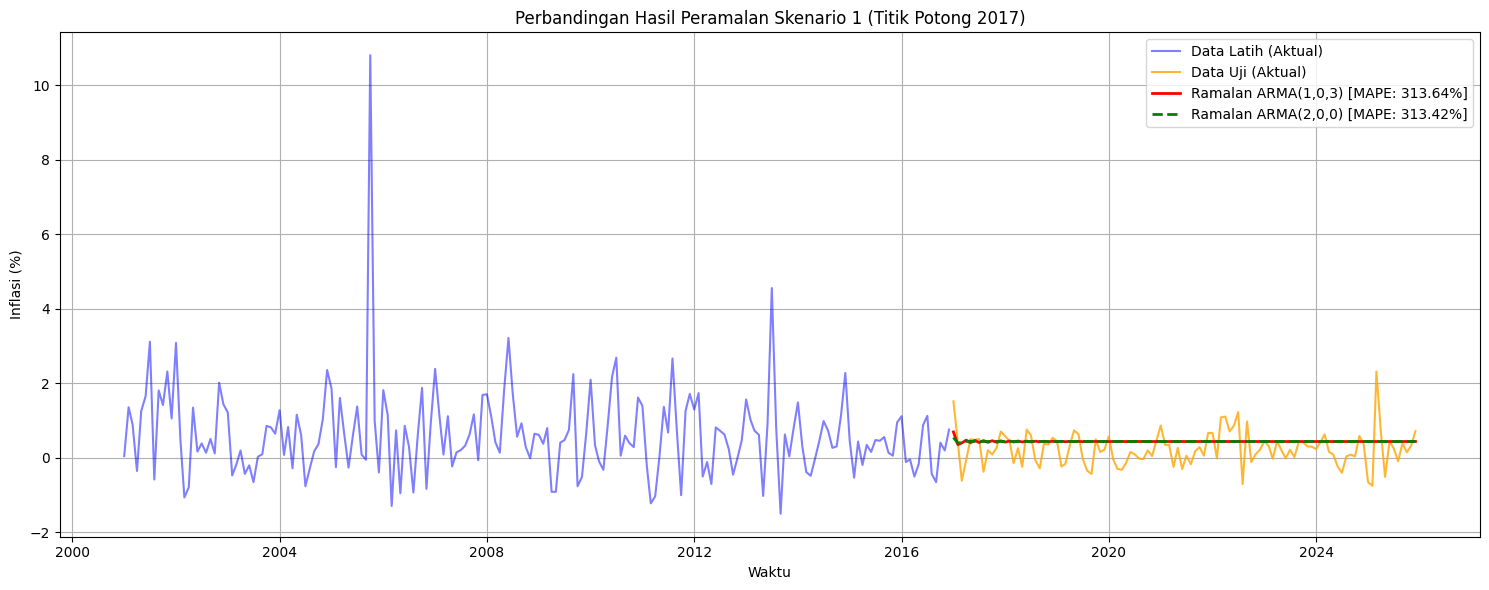

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

print("=== FORECASTING & EVALUASI SKENARIO 1 (TITIK POTONG JAN 2017) ===\n")

# Mengambil data dan parameter Box-Cox khusus Skenario 1
nama_skenario = "Skenario 1 (2001-2016)"
train_bc = hasil_boxcox[nama_skenario]['train_bc']
opt_lambda = hasil_boxcox[nama_skenario]['lambda']
shift = hasil_boxcox[nama_skenario]['shift']

# Data aktual untuk perbandingan (skala asli)
aktual_train = train_1
aktual_test = test_1
aktual_aman = np.where(aktual_test.values == 0, 1e-10, aktual_test.values) # Mencegah error pembagian 0

# --- 1. MODEL 1: ARMA(1,0,3) (Juara AIC) ---
model_1 = ARIMA(train_bc, order=(1, 0, 3))
hasil_1 = model_1.fit()
ramalan_bc_1 = hasil_1.forecast(steps=len(aktual_test))
ramalan_bc_1.index = aktual_test.index
# Inverse ke skala asli
ramalan_asli_1 = inv_boxcox(ramalan_bc_1, opt_lambda) - shift

# Hitung Error
rmse_1 = np.sqrt(np.mean((aktual_test.values - ramalan_asli_1.values)**2))
mape_1 = np.mean(np.abs((aktual_test.values - ramalan_asli_1.values) / aktual_aman)) * 100

# --- 2. MODEL 2: ARMA(2,0,0) (Juara BIC) ---
model_2 = ARIMA(train_bc, order=(2, 0, 0))
hasil_2 = model_2.fit()
ramalan_bc_2 = hasil_2.forecast(steps=len(aktual_test))
ramalan_bc_2.index = aktual_test.index
# Inverse ke skala asli
ramalan_asli_2 = inv_boxcox(ramalan_bc_2, opt_lambda) - shift

# Hitung Error
rmse_2 = np.sqrt(np.mean((aktual_test.values - ramalan_asli_2.values)**2))
mape_2 = np.mean(np.abs((aktual_test.values - ramalan_asli_2.values) / aktual_aman)) * 100

# --- 3. MENAMPILKAN HASIL EVALUASI ---
print("Hasil Evaluasi Skenario 1 (Out-of-Sample):")
print(f"Model ARMA(1,0,3) -> RMSE: {rmse_1:.4f}% | MAPE: {mape_1:.2f}%")
print(f"Model ARMA(2,0,0) -> RMSE: {rmse_2:.4f}% | MAPE: {mape_2:.2f}%")

# --- 4. VISUALISASI HASIL FORECASTING ---
plt.figure(figsize=(15, 6))

# Plot Aktual (Train & Test)
plt.plot(aktual_train.index, aktual_train.values, label="Data Latih (Aktual)", color="blue", alpha=0.5)
plt.plot(aktual_test.index, aktual_test.values, label="Data Uji (Aktual)", color="orange", alpha=0.8)

# Plot Ramalan
plt.plot(ramalan_asli_1.index, ramalan_asli_1.values, label=f"Ramalan ARMA(1,0,3) [MAPE: {mape_1:.2f}%]", color="red", linewidth=2)
plt.plot(ramalan_asli_2.index, ramalan_asli_2.values, label=f"Ramalan ARMA(2,0,0) [MAPE: {mape_2:.2f}%]", color="green", linewidth=2, linestyle='--')

plt.title("Perbandingan Hasil Peramalan Skenario 1 (Titik Potong 2017)")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Fenomena Garis Lurus (Mean Reversion): Pada grafik, garis ramalan merah dan hijau putus-putus terlihat mendatar lurus. Ini adalah karakteristik alami dari model ARMA yang stasioner ketika dipaksa melakukan peramalan jangka panjang (long-horizon forecast), yaitu 9 tahun ke depan tanpa asupan data baru. Model akan dengan cepat meredam fluktuasi dan kembali ke nilai rata-rata (mean reversion) dari data historisnya.

- Mengapa MAPE Meledak (>300%)?: Nilai MAPE yang mencapai 313% bukan berarti modelmu sepenuhnya gagal. Data inflasi memiliki nilai yang sangat mendekati nol, bahkan negatif (deflasi). Rumus MAPE membagi nilai selisih tebakan dengan nilai aktual. Secara matematis, membagi angka apapun dengan angka yang nyaris nol akan menghasilkan persentase yang tak terhingga besarnya. Ini adalah kelemahan fatal MAPE pada data yang melewati garis nol.

- RMSE Lebih Realistis: Nilai RMSE berada di angka 0.4933% (ARMA(1,0,3)) dan 0.4958% (ARMA(2,0,0)). Secara absolut, meleset sekitar 0,49% untuk ukuran pergerakan inflasi sebenarnya masih cukup masuk akal. Secara performa, kedua model ini memberikan hasil yang nyaris identik.

**Skenario 2: Visualisasi Diagnostik Sisaan**

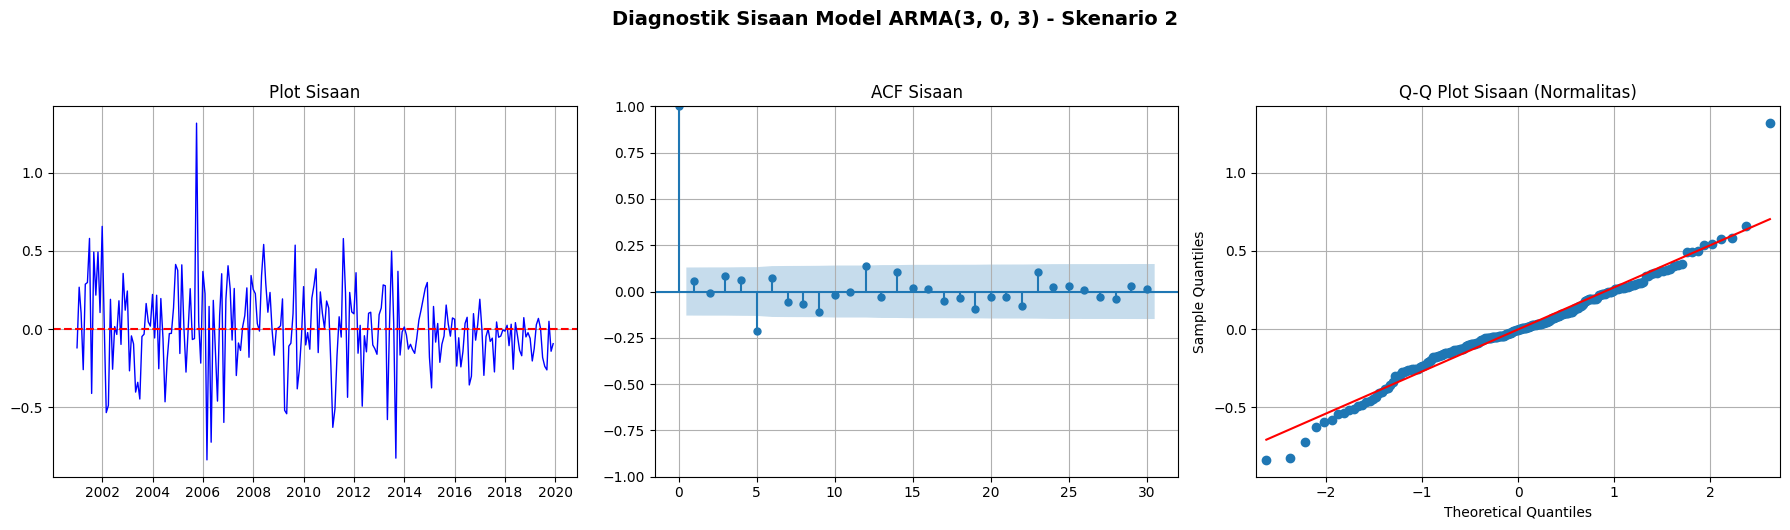

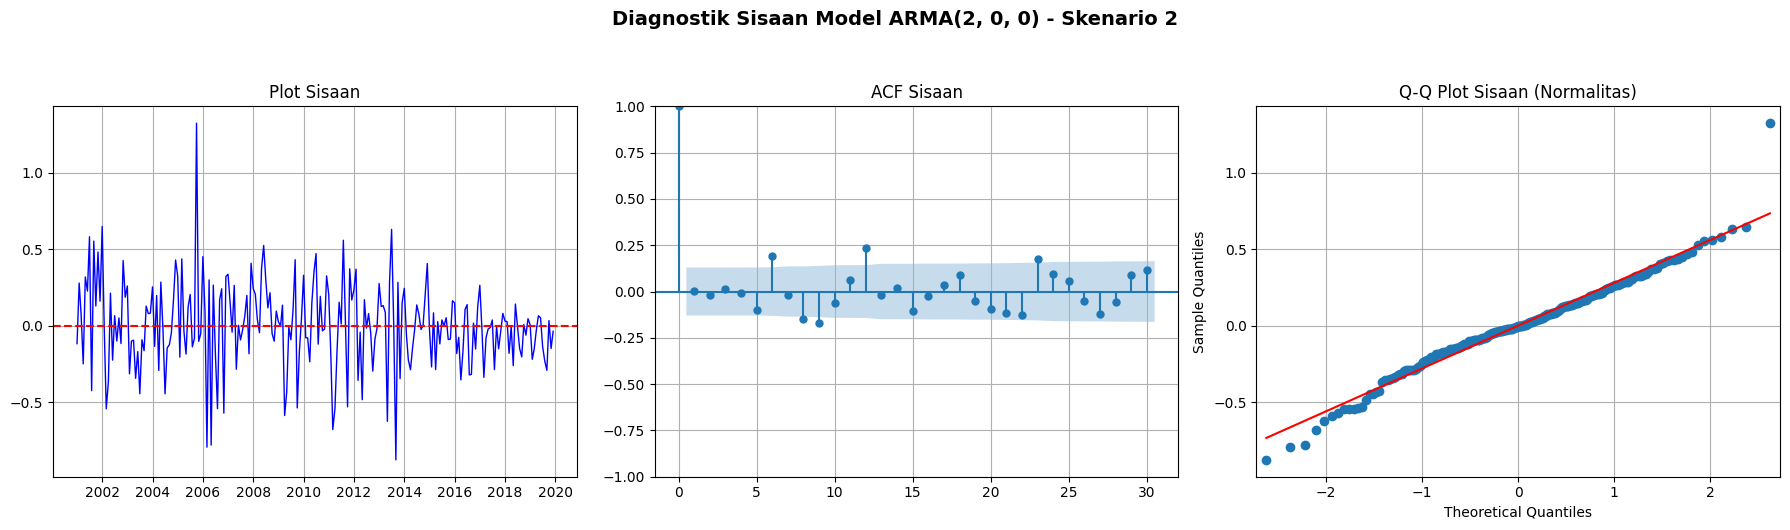

In [81]:
# Visualisasi Diagnostik Sisaan

# Setup Data Skenario 2
nama_skenario = "Skenario 2 (2001-2019)"
train_bc = hasil_boxcox[nama_skenario]['train_bc']
opt_lambda = hasil_boxcox[nama_skenario]['lambda']
shift = hasil_boxcox[nama_skenario]['shift']

aktual_train = train_2
aktual_test = test_2
aktual_aman = np.where(aktual_test.values == 0, 1e-10, aktual_test.values)

kandidat_skenario_2 = [(3, 0, 3), (2, 0, 0)]
warna_plot = ['red', 'green']
hasil_skenario_2 = []
ramalan_dict = {}

# 1. Evaluasi & Forecasting
for i, orde in enumerate(kandidat_skenario_2):
    model = ARIMA(train_bc, order=orde)
    hasil = model.fit()

    # Simpan hasil untuk diagnostik nanti
    hasil_skenario_2.append((orde, hasil))

for orde, hasil in hasil_skenario_2:
    sisaan = hasil.resid
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Diagnostik Sisaan Model ARMA{orde} - Skenario 2", fontsize=14, fontweight='bold', y=1.05)

    axes[0].plot(sisaan.index, sisaan.values, color='blue', linewidth=1)
    axes[0].set_title("Plot Sisaan")
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].grid(True)

    sm.graphics.tsa.plot_acf(sisaan, lags=30, ax=axes[1])
    axes[1].set_title("ACF Sisaan")
    axes[1].grid(True)

    sm.qqplot(sisaan, line='s', ax=axes[2])
    axes[2].set_title("Q-Q Plot Sisaan (Normalitas)")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

Plot diagnostik menunjukkan masalah yang sama dengan Skenario 1. Terdapat spike (lonjakan) yang signifikan pada ACF Sisaan di lag 12 untuk kedua model, membuktikan bahwa pola musiman tahunan masih tertinggal di dalam sisaan dan tidak ditangkap oleh model. Q-Q Plot juga menunjukkan penyimpangan di kedua ekor (heavy tails), menandakan sisaan tidak berdistribusi normal akibat efek outlier masa lalu yang masih membekas.

**Skenario 2: Forecasting**

=== FORECASTING & EVALUASI SKENARIO 2 (TITIK POTONG JAN 2020) ===

Model ARMA(3, 0, 3) -> RMSE: 0.5046% | MAPE: 328.24%
Model ARMA(2, 0, 0) -> RMSE: 0.4977% | MAPE: 338.84%
----------------------------------------------------------------------------------------------------


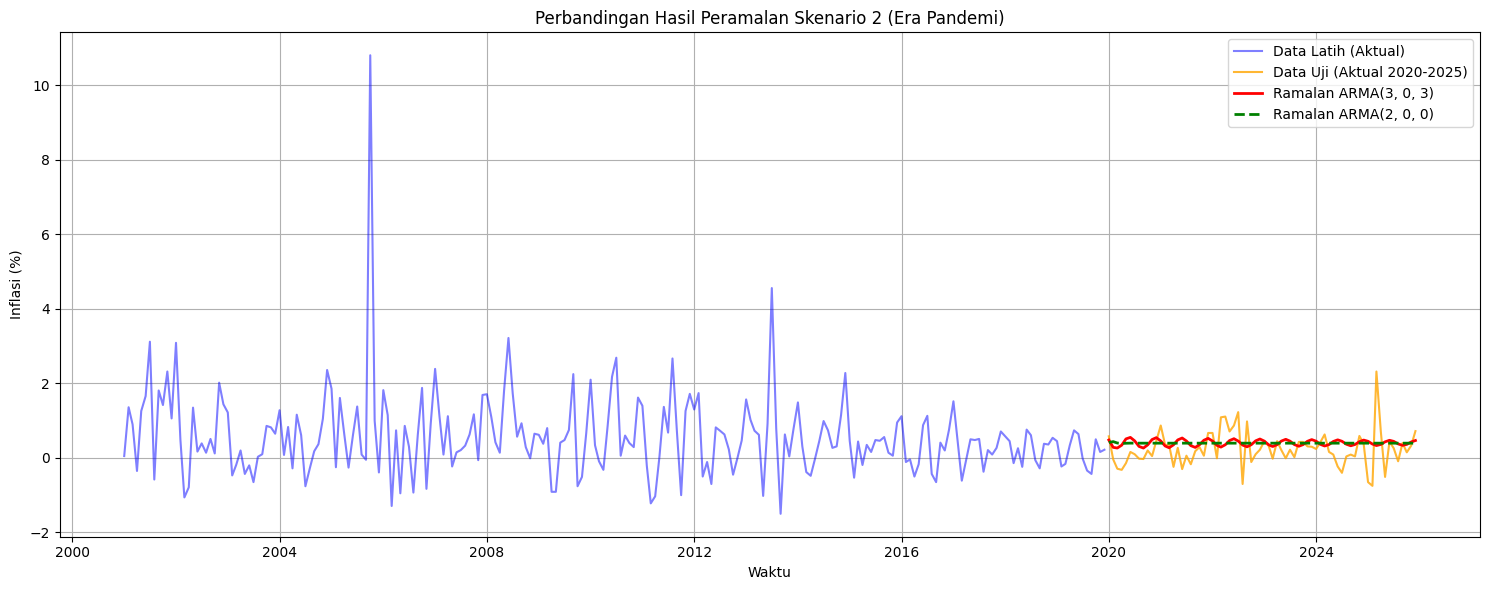

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

print("=== FORECASTING & EVALUASI SKENARIO 2 (TITIK POTONG JAN 2020) ===\n")

# Setup Data Skenario 2
nama_skenario = "Skenario 2 (2001-2019)"
train_bc = hasil_boxcox[nama_skenario]['train_bc']
opt_lambda = hasil_boxcox[nama_skenario]['lambda']
shift = hasil_boxcox[nama_skenario]['shift']

aktual_train = train_2
aktual_test = test_2
aktual_aman = np.where(aktual_test.values == 0, 1e-10, aktual_test.values)

kandidat_skenario_2 = [(3, 0, 3), (2, 0, 0)]
warna_plot = ['red', 'green']
hasil_skenario_2 = []
ramalan_dict = {}

# 1. Evaluasi & Forecasting
for i, orde in enumerate(kandidat_skenario_2):
    model = ARIMA(train_bc, order=orde)
    hasil = model.fit()

    # Simpan hasil untuk diagnostik nanti
    hasil_skenario_2.append((orde, hasil))

    ramalan_bc = hasil.forecast(steps=len(aktual_test))
    ramalan_bc.index = aktual_test.index
    ramalan_asli = inv_boxcox(ramalan_bc, opt_lambda) - shift
    ramalan_dict[f"ARMA{orde}"] = ramalan_asli

    rmse = np.sqrt(np.mean((aktual_test.values - ramalan_asli.values)**2))
    mape = np.mean(np.abs((aktual_test.values - ramalan_asli.values) / aktual_aman)) * 100
    print(f"Model ARMA{orde} -> RMSE: {rmse:.4f}% | MAPE: {mape:.2f}%")

print("-" * 100)

# 2. Visualisasi Forecasting
plt.figure(figsize=(15, 6))
plt.plot(aktual_train.index, aktual_train.values, label="Data Latih (Aktual)", color="blue", alpha=0.5)
plt.plot(aktual_test.index, aktual_test.values, label="Data Uji (Aktual 2020-2025)", color="orange", alpha=0.8)

for i, orde in enumerate(kandidat_skenario_2):
    plt.plot(ramalan_dict[f"ARMA{orde}"].index, ramalan_dict[f"ARMA{orde}"].values,
             label=f"Ramalan ARMA{orde}", color=warna_plot[i], linewidth=2, linestyle='-' if i==0 else '--')

plt.title("Perbandingan Hasil Peramalan Skenario 2 (Era Pandemi)")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Hasil evaluasi dan diagnostik dari Skenario 2 memberikan gambaran yang konsisten dengan keterbatasan model ARMA pada data musiman:

- Perbandingan Error: Model ARMA(2,0,0) unggul tipis pada metrik RMSE dengan nilai 0,4977% dibandingkan ARMA(3,0,3) yang bernilai 0,5046%. Sebaliknya, ARMA(3,0,3) sedikit lebih baik pada MAPE (328,24% vs 338,84%). Angka MAPE yang meledak di atas 300% kembali terjadi karena pembagian dengan nilai aktual inflasi yang mendekati nol. Dengan performa yang berimbang ini, ARMA(2,0,0) tetap lebih diunggulkan karena prinsip parsimoni (lebih sederhana).

- Karakteristik Peramalan: Grafik peramalan menunjukkan bahwa ARMA(3,0,3) (garis merah) sempat mencoba menangkap sedikit pola gelombang di awal periode 2020 sebelum akhirnya mendatar. Sementara itu, ARMA(2,0,0) (garis hijau) nyaris langsung mendatar (mean reversion). Kedua model ini tidak mampu memprediksi gejolak nyata inflasi (garis oranye) yang terjadi selama periode pandemi hingga pemulihannya.

**Skenario 3: Visualisasi Diagnostik Sisaan**

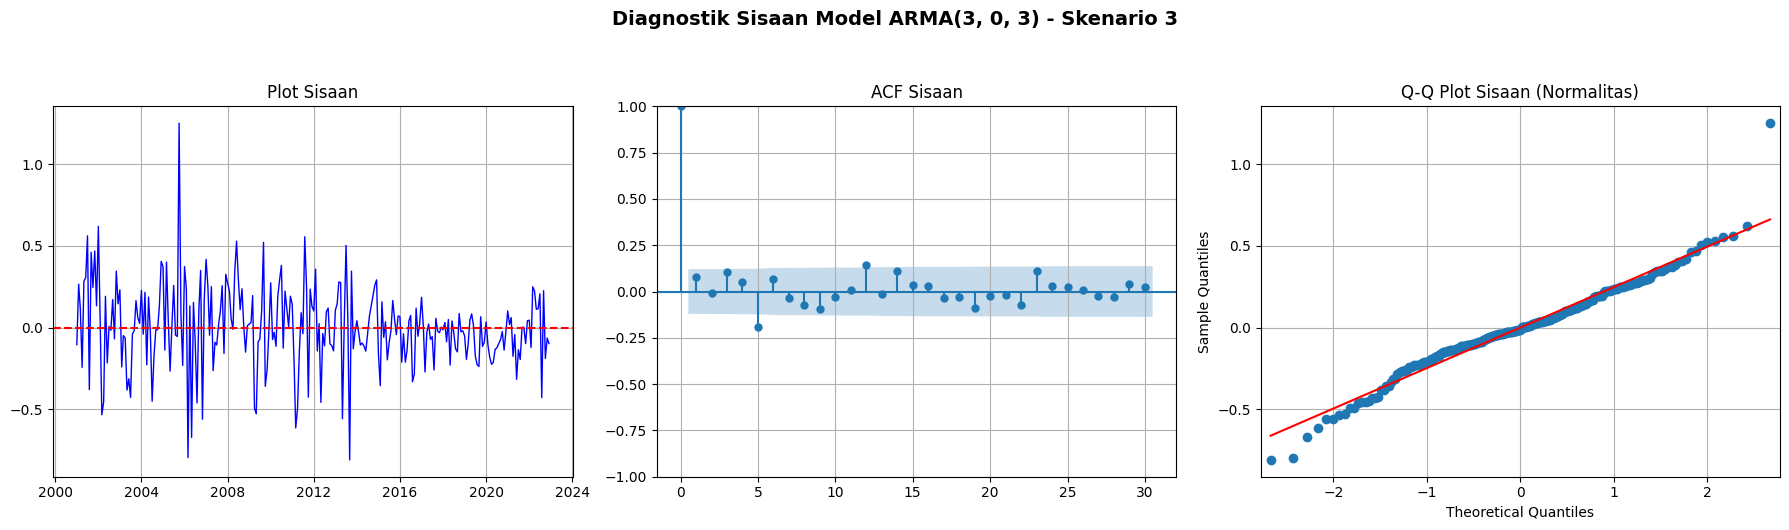

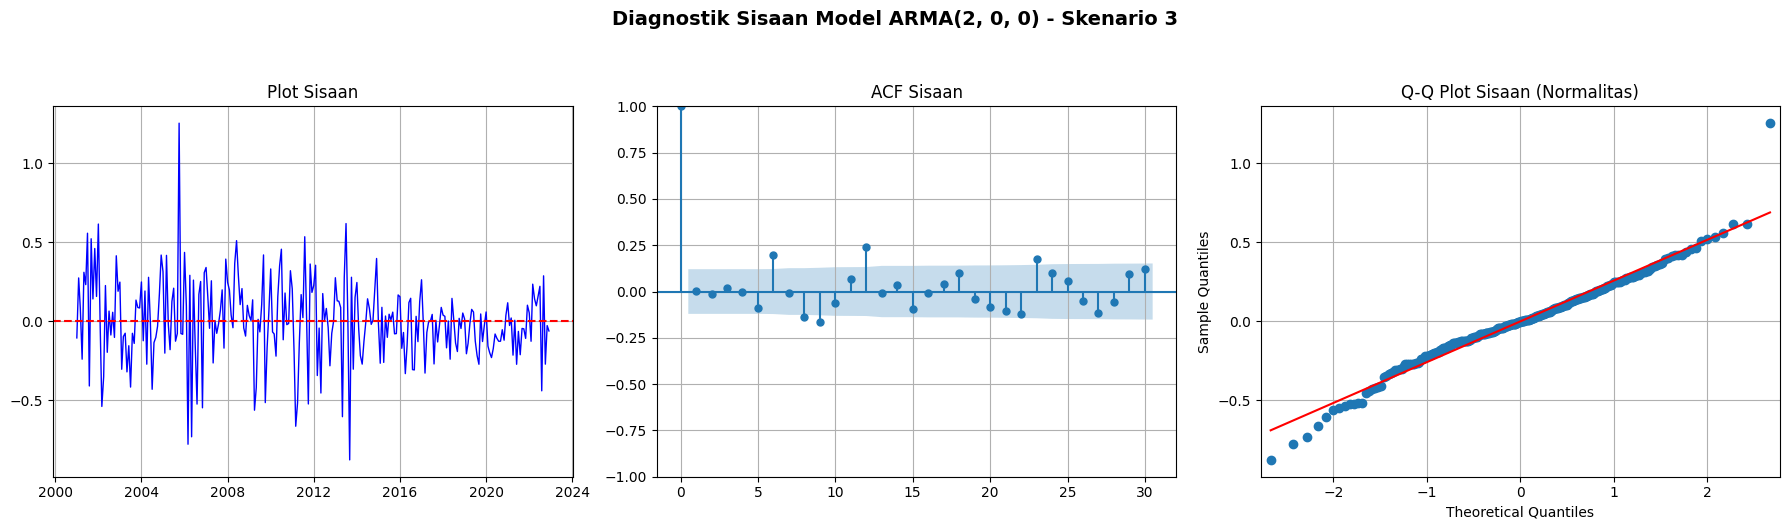

In [79]:
# Visualisasi Diagnostik Sisaan


# Setup Data Skenario 3
nama_skenario = "Skenario 3 (2001-2022)"
train_bc = hasil_boxcox[nama_skenario]['train_bc']
opt_lambda = hasil_boxcox[nama_skenario]['lambda']
shift = hasil_boxcox[nama_skenario]['shift']

aktual_train = train_3
aktual_test = test_3
aktual_aman = np.where(aktual_test.values == 0, 1e-10, aktual_test.values)

kandidat_skenario_3 = [(3, 0, 3), (2, 0, 0)]
warna_plot = ['red', 'green']
hasil_skenario_3 = []
ramalan_dict = {}

# 1. Evaluasi & Forecasting
for i, orde in enumerate(kandidat_skenario_3):
    model = ARIMA(train_bc, order=orde)
    hasil = model.fit()

    # Simpan hasil untuk diagnostik nanti
    hasil_skenario_3.append((orde, hasil))

for orde, hasil in hasil_skenario_3:
    sisaan = hasil.resid
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Diagnostik Sisaan Model ARMA{orde} - Skenario 3", fontsize=14, fontweight='bold', y=1.05)

    axes[0].plot(sisaan.index, sisaan.values, color='blue', linewidth=1)
    axes[0].set_title("Plot Sisaan")
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].grid(True)

    sm.graphics.tsa.plot_acf(sisaan, lags=30, ax=axes[1])
    axes[1].set_title("ACF Sisaan")
    axes[1].grid(True)

    sm.qqplot(sisaan, line='s', ax=axes[2])
    axes[2].set_title("Q-Q Plot Sisaan (Normalitas)")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

**Skenario 3: Forecasting**

=== FORECASTING & EVALUASI SKENARIO 3 (TITIK POTONG JAN 2023) ===

Model ARMA(3, 0, 3) -> RMSE: 0.5247% | MAPE: 326.85%
Model ARMA(2, 0, 0) -> RMSE: 0.5101% | MAPE: 329.55%
----------------------------------------------------------------------------------------------------


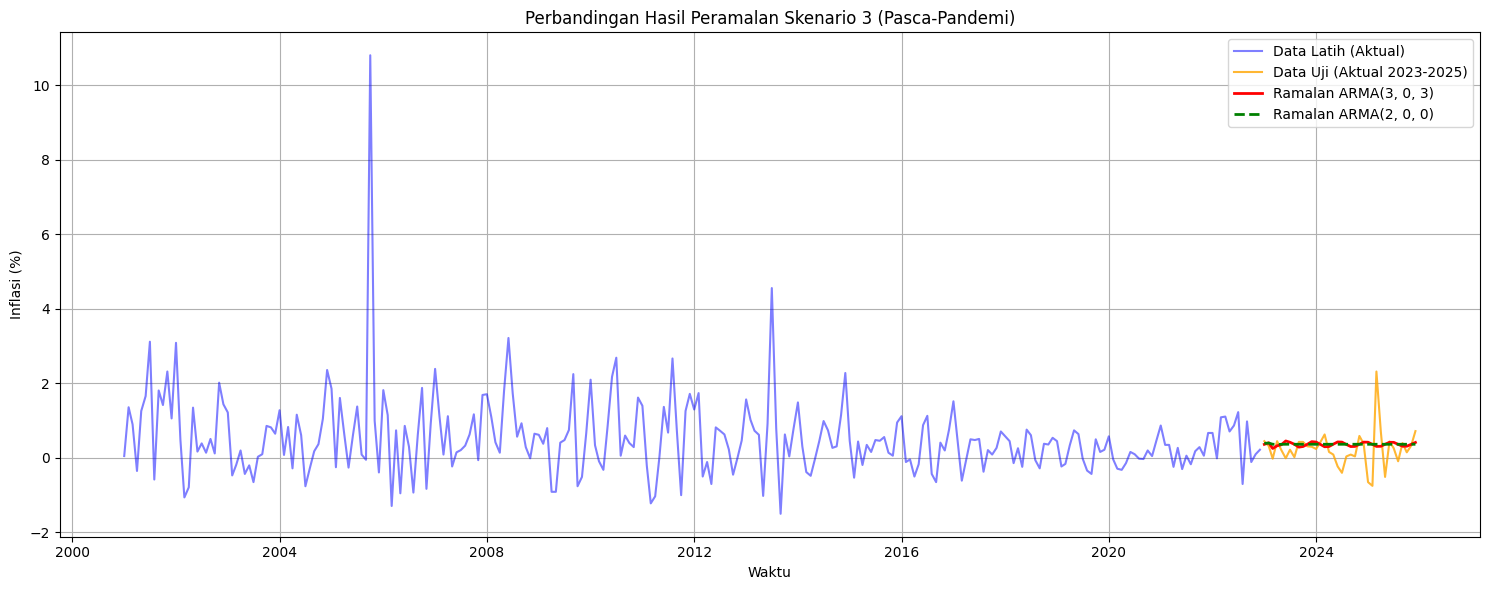

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

print("=== FORECASTING & EVALUASI SKENARIO 3 (TITIK POTONG JAN 2023) ===\n")

# Setup Data Skenario 3
nama_skenario = "Skenario 3 (2001-2022)"
train_bc = hasil_boxcox[nama_skenario]['train_bc']
opt_lambda = hasil_boxcox[nama_skenario]['lambda']
shift = hasil_boxcox[nama_skenario]['shift']

aktual_train = train_3
aktual_test = test_3
aktual_aman = np.where(aktual_test.values == 0, 1e-10, aktual_test.values)

kandidat_skenario_3 = [(3, 0, 3), (2, 0, 0)]
warna_plot = ['red', 'green']
hasil_skenario_3 = []
ramalan_dict = {}

# 1. Evaluasi & Forecasting
for i, orde in enumerate(kandidat_skenario_3):
    model = ARIMA(train_bc, order=orde)
    hasil = model.fit()

    # Simpan hasil untuk diagnostik nanti
    hasil_skenario_3.append((orde, hasil))

    ramalan_bc = hasil.forecast(steps=len(aktual_test))
    ramalan_bc.index = aktual_test.index
    ramalan_asli = inv_boxcox(ramalan_bc, opt_lambda) - shift
    ramalan_dict[f"ARMA{orde}"] = ramalan_asli

    rmse = np.sqrt(np.mean((aktual_test.values - ramalan_asli.values)**2))
    mape = np.mean(np.abs((aktual_test.values - ramalan_asli.values) / aktual_aman)) * 100
    print(f"Model ARMA{orde} -> RMSE: {rmse:.4f}% | MAPE: {mape:.2f}%")

print("-" * 100)

# 2. Visualisasi Forecasting
plt.figure(figsize=(15, 6))
plt.plot(aktual_train.index, aktual_train.values, label="Data Latih (Aktual)", color="blue", alpha=0.5)
plt.plot(aktual_test.index, aktual_test.values, label="Data Uji (Aktual 2023-2025)", color="orange", alpha=0.8)

for i, orde in enumerate(kandidat_skenario_3):
    plt.plot(ramalan_dict[f"ARMA{orde}"].index, ramalan_dict[f"ARMA{orde}"].values,
             label=f"Ramalan ARMA{orde}", color=warna_plot[i], linewidth=2, linestyle='-' if i==0 else '--')

plt.title("Perbandingan Hasil Peramalan Skenario 3 (Pasca-Pandemi)")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [82]:
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore") # Menyembunyikan peringatan konvergensi

print("=== TRIAL & ERROR MODEL ARMA PADA 3 SKENARIO PEMBAGIAN DATA ===\n")

# Menyiapkan data Test asli untuk perhitungan error (agar akurat di skala aslinya)
skenario_test = {
    "Skenario 1 (2017)": test_1,
    "Skenario 2 (2020)": test_2,
    "Skenario 3 (2023)": test_3
}

# Mapping nama skenario antara train (hasil_boxcox) dan test
mapping_nama = {
    "Skenario 1 (2001-2016)": "Skenario 1 (2017)",
    "Skenario 2 (2001-2019)": "Skenario 2 (2020)",
    "Skenario 3 (2001-2022)": "Skenario 3 (2023)"
}

# Kandidat ordo ARMA yang akan diuji (d=0 karena data sudah stasioner)
kandidat_orde = [(1,0,0), (2,0,0), (1,0,1), (2,0,1), (2,0,2), (3,0,0)]

hasil_evaluasi = []

# Looping untuk setiap skenario data latih yang sudah di-Box-Cox
for nama_train, data_dict in hasil_boxcox.items():
    train_bc = data_dict['train_bc']
    opt_lambda = data_dict['lambda']
    shift = data_dict['shift']

    # Mengambil data test asli yang bersesuaian
    nama_test = mapping_nama[nama_train]
    aktual_test_asli = skenario_test[nama_test]

    # Pengamanan jika ada nilai aktual 0 untuk perhitungan MAPE
    aktual_aman = np.where(aktual_test_asli == 0, 1e-10, aktual_test_asli)

    for orde in kandidat_orde:
        try:
            # 1. Fit Model ARMA pada data latih Box-Cox
            model = ARIMA(train_bc, order=orde)
            hasil_model = model.fit()

            # 2. Forecast sepanjang data uji
            ramalan_bc = hasil_model.forecast(steps=len(aktual_test_asli))

            # 3. Inverse Box-Cox ke skala inflasi asli
            ramalan_asli = inv_boxcox(ramalan_bc, opt_lambda) - shift

            # 4. Hitung Metrik Evaluasi (RMSE dan MAPE)
            rmse = np.sqrt(np.mean((aktual_test_asli.values - ramalan_asli.values)**2))
            mape = np.mean(np.abs((aktual_test_asli.values - ramalan_asli.values) / aktual_aman)) * 100

            # 5. Simpan Hasil
            hasil_evaluasi.append({
                "Skenario Pemotongan": nama_test,
                "Orde Model": f"ARMA{orde}",
                "RMSE (%)": rmse,
                "MAPE (%)": mape
            })

        except Exception as e:
            continue # Lewati jika model gagal konvergen secara matematis

# Membuat DataFrame dari hasil evaluasi
df_evaluasi = pd.DataFrame(hasil_evaluasi)

# Mengurutkan berdasarkan MAPE terkecil
df_evaluasi_sorted = df_evaluasi.sort_values(by="MAPE (%)").reset_index(drop=True)

print("Tabel Peringkat Model dan Skenario Terbaik (Berdasarkan MAPE):")
display(df_evaluasi_sorted.head(15))

=== TRIAL & ERROR MODEL ARMA PADA 3 SKENARIO PEMBAGIAN DATA ===

Tabel Peringkat Model dan Skenario Terbaik (Berdasarkan MAPE):


,Skenario Pemotongan,Orde Model,RMSE (%),MAPE (%)
0,Skenario 1 (2017),"ARMA(2, 0, 0)",0.495801,313.416157
1,Skenario 1 (2017),"ARMA(2, 0, 2)",0.495105,313.497021
2,Skenario 1 (2017),"ARMA(3, 0, 0)",0.495920,313.536765
3,Skenario 1 (2017),"ARMA(2, 0, 1)",0.495895,313.635262
4,Skenario 1 (2017),"ARMA(1, 0, 1)",0.496617,313.702978
5,Skenario 1 (2017),"ARMA(1, 0, 0)",0.497701,313.799777
6,Skenario 3 (2023),"ARMA(1, 0, 1)",0.510278,329.183311
7,Skenario 3 (2023),"ARMA(1, 0, 0)",0.510090,329.274790
8,Skenario 3 (2023),"ARMA(3, 0, 0)",0.510023,329.362326
9,Skenario 3 (2023),"ARMA(2, 0, 1)",0.510049,329.408223
